In [10]:
"""
En este script se vera si la muestra de los stamps
es representativa o no.
"""

'\nEn este script se vera si la muestra de los stamps\nes representativa o no.\n'

In [3]:
# Importación de librerías importantes

import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

import astropy 
from pathlib import Path 
from astropy.table import Table 
from astropy.coordinates import SkyCoord 
import astropy.units as u

import os, urllib.request, urllib.error, time, http.client
from astropy.table import unique, vstack

import tarfile, io
import numpy as np
import matplotlib.pyplot as plt
import re

In [4]:
### SE CARGA LA MUESTRA COMPLETA
FILE_PATH_COSMOS = "../../data/COSMOS_galaxies_20260618.txt"
df_cosmos = pd.read_csv(FILE_PATH_COSMOS, sep=",")
df_cosmos.info()

<class 'pandas.DataFrame'>
RangeIndex: 641437 entries, 0 to 641436
Data columns (total 55 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ra                  641437 non-null  float64
 1   dec                 641437 non-null  float64
 2   type                641437 non-null  str    
 3   shape_r             641437 non-null  float64
 4   shape_e1            641437 non-null  float64
 5   shape_e2            641437 non-null  float64
 6   sersic              641437 non-null  float64
 7   ebv                 641437 non-null  float64
 8   release             641437 non-null  int64  
 9   brickid             641437 non-null  int64  
 10  objid               641437 non-null  int64  
 11  brick_primary       641437 non-null  bool   
 12  brickname           641437 non-null  str    
 13  maskbits            641437 non-null  int64  
 14  fitbits             641437 non-null  int64  
 15  flux_g              641437 non-null  float64


In [5]:
df_cosmos.columns.tolist()
# se renombra la columna id por desi_id
df_cosmos.rename(columns={"targetid": "desi_id"}, inplace=True)
# se eliminan columnas inutiles
df_cosmos.drop(columns=["zwarn", "spectype", "survey", "release", "dist_deg", "Separation", "brick_primary"], inplace=True)

In [6]:
##### SE CARGAN LAS FEATURES DE LA SUBMUESTRA DE STAMPS
FILE_PATH_FEATURES = "../../data/features_images_20260618.csv"
df_features_images = pd.read_csv(FILE_PATH_FEATURES, sep=",")

In [ ]:
# Lectura de archivos: STAMPS

FILE_IMAGES = "../../data/cosmos_TC_202602.tar.gz.part_aa"

def load_all(path):
    """Read all .npy files from a tar.gz archive, tolerates truncated files."""
    arrays, names = [], []
    try:
        with tarfile.open(path, "r|gz") as tar:  # r|gz = streaming, handles truncation
            for m in tar:
                if not m.name.endswith(".npy"):
                    continue
                f = tar.extractfile(m)
                if f is None:
                    continue
                arrays.append(np.load(io.BytesIO(f.read())))
                names.append(m.name.split("/")[-1].replace(".npy", ""))
    except (EOFError, tarfile.ReadError):
        print(f"Archivo truncado -- se recuperaron {len(arrays)} galaxias antes del corte.")
    return arrays, names

arrays, names = load_all(FILE_IMAGES)

In [7]:
##### SE PRINTEA EL TAMAÑO DE LOS DFS
print(f"Tamaño df_cosmos: {df_cosmos.shape}")
print(f"Tamaño df_feat: {df_features_images.shape}")

Tamaño df_cosmos: (641437, 48)
Tamaño df_feat: (29575, 48)


**Comentario** Originalmente son ~32,900 stamps, pero no todos tienen features asociados. Solo 29,575 stamps poseen features.

In [ ]:
## De acuerdo a la siguiente referencia: 10.3847/1538-3881/ad7c52
## Se consideran los objetos que tengan maskbits igual a 0:
## tanto de la muestra general como de la submuestra a trabajar

print(f"Cantidad de objetos ANTES de filtrar por maskbits=0 (muestra general) {df_cosmos.shape[0]}")
print(f"Cantidad de objetos ANTES de filtrar por maskbits=0 (submuestra) {df_features_images.shape[0]}")

## FILTRO 1: SE CONSIDERAN LOS OBJETOS CUYOS MASKBISTS == 0.

df_cosmos = df_cosmos[df_cosmos["maskbits"] == 0].copy()
df_features_images = df_features_images[df_features_images["maskbits"] == 0].copy()

print(f"Cantidad de objetos DESPUÉS de filtrar por maskbits=0 (muestra general) {df_cosmos.shape[0]}")
print(f"Cantidad de objetos DESPUÉS de filtrar por maskbits=0 (submuestra) {df_features_images.shape[0]}")


Cantidad de objetos ANTES de filtrar por maskbits=0 (muestra general) 641437
Cantidad de objetos ANTES de filtrar por maskbits=0 (submuestra) 29575
Cantidad de objetos DESPUÉS de filtrar por maskbits=0 (muestra general) 601614
Cantidad de objetos DESPUÉS de filtrar por maskbits=0 (submuestra) 27757


In [20]:
# SEGUNDO FILTRADO
# Consideramos aquellos objetos que presenten flujos positivos, esto es
# para obtener magnitudes y colores para trabajos posterior.

df_features_images = df_features_images.query("flux_g > 0 and flux_r > 0 and flux_i > 0 and flux_z > 0").copy()
print(f"Cantidad de objetos con stamps disponibles: {df_features_images.shape[0]}")

Cantidad de objetos con stamps disponibles: 26166


In [18]:
# Verificar que todos los stamps tienen el mismo tamaño (esperado: 30×30)
shapes = [a.shape for a in arrays]
unique_shapes = set(shapes)

print(f"Shape de ejemplo (arrays[0]): {arrays[0].shape}")
print(f"Shapes distintas encontradas: {unique_shapes}")

todas_iguales = len(unique_shapes) == 1
dims_espaciales = list(unique_shapes)[0][-2:] if todas_iguales else None

print(f"¿Todos tienen el mismo shape? {'Sí' if todas_iguales else 'No'}")

if todas_iguales:
    print(f"¿Dimensiones espaciales 30×30? {'Sí' if dims_espaciales == (30, 30) else f'No — son {dims_espaciales}'}")

Shape de ejemplo (arrays[0]): (4, 5, 30, 30)
Shapes distintas encontradas: {(4, 5, 30, 30)}
¿Todos tienen el mismo shape? Sí
¿Dimensiones espaciales 30×30? Sí


In [10]:
################################################
#### COMPARACIÓN DISTRIBUCIONES DE MUESTRAS

def compare_dist(col, bins=80, log_x=False, xlabel=None, plot_type="hist"):
    """
    Compara la distribución de `col` en df_cosmos y df_features_images.
    plot_type : "hist" (por defecto) o "violin".
    log_x     : aplica log10 filtrando valores <= 0 antes de graficar.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
    label_x = xlabel or (f"log10({col})" if log_x else col)

    for ax, df, title in zip(
        axes,
        [df_cosmos, df_features_images],
        [f"df_cosmos  (n={len(df_cosmos):,})", f"df_features_images  (n={len(df_features_images):,})"],
    ):
        vals = df[col].dropna()
        if log_x:
            vals = np.log10(vals[vals > 0])

        if plot_type == "violin":
            ax.violinplot(vals, showmedians=True)
            ax.set_xticks([])
            ax.set_ylabel(label_x)
        else:
            ax.hist(vals, bins=bins, density=True, edgecolor="k", linewidth=0.2)
            ax.set_xlabel(label_x)
            ax.set_ylabel("densidad")

        ax.set_title(title)

    plt.suptitle(col)
    plt.tight_layout()
    plt.show()

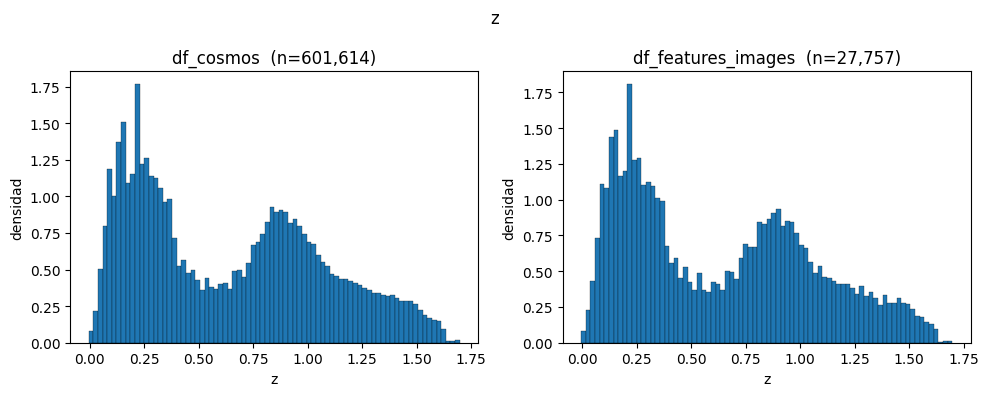

In [17]:
# Redshift espectroscópico
compare_dist("z", bins=80)


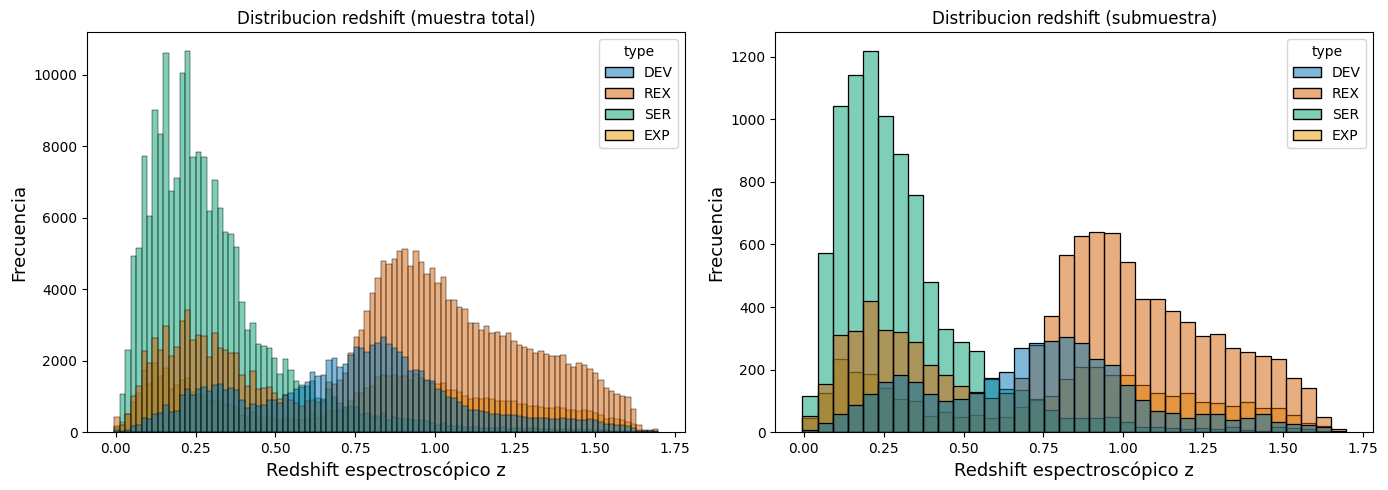

In [19]:
# Colores fijos por tipo morfologico
type_colors = {
    'DEV': '#0072B2',
    'REX': '#D55E00',
    'SER': '#009E73',
    'EXP': '#E69F00',
    # agrega los tipos que tengas
}

# Para que el orden de la leyenda sea consistente tambien
type_order = list(type_colors.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_cosmos, x="z", hue="type",
             palette=type_colors, hue_order=type_order, ax=axes[0])
axes[0].set_title("Distribucion redshift (muestra total)")
axes[0].set_ylabel("Frecuencia", fontsize=13)
axes[0].set_xlabel("Redshift espectroscópico z", fontsize=13)

sns.histplot(data=df_features_images, x="z", hue="type",
             palette=type_colors, hue_order=type_order, ax=axes[1])
axes[1].set_title("Distribucion redshift (submuestra)")
axes[1].set_ylabel("Frecuencia", fontsize=13)
axes[1].set_xlabel("Redshift espectroscópico z", fontsize=13)

plt.tight_layout()
plt.show()

'\n- Z y shape_r están moderadamente correlacionados.\n- Lo que llama la atención es la correlación perfecta entre los supuestos\n    coeficientes de transmisión.\n'

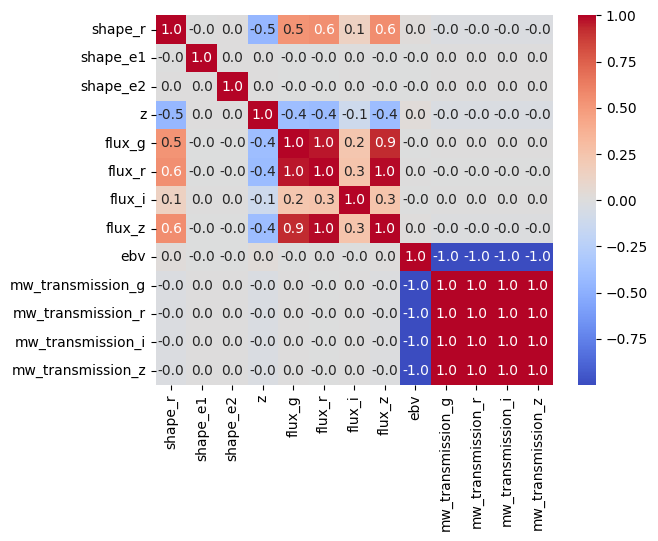

In [21]:
## MATRIZ DE CORRELACIÓN DE LAS VARIABLES QUE IMPORTAN

## VARIABLES DE INTERES: FLUJOS, EBV, SHAPE_R, SHAPE_E1, SHAPE_E2
num_cols = ["shape_r", "shape_e1", "shape_e2", "z", 
            "flux_g", "flux_r", "flux_i", "flux_z",
            "ebv", 
            "mw_transmission_g", "mw_transmission_r",   "mw_transmission_i", "mw_transmission_z"]
corr = df_cosmos[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", )

"""
- Z y shape_r están moderadamente correlacionados.
- Lo que llama la atención es la correlación perfecta entre los supuestos
    coeficientes de transmisión.
"""

**Comentario**: Los coeficientes de transmisión tienen una correlación lineal negativa con la Extinción de color E(B-V) por se relacion de la siguiente manera:

$$
T_\lambda = 10^{-0.4 * R_\lambda * E(B-V)}
$$

Ya, esto viene por lo siguiente:
Si tengo una fuente con una magnitud intrínceca $m_{int}$, hay polvo a lo largo de la line of sight que extingue esa magnitud/brillo. Cuando es una fuente puntual, es la extinción, pero cuando se trata de galaxias, es la atenuación.

$$
m_{observado} = m_{int} + A_\lambda.
$$

$$

A_\lambda = R_\lambda E(B-V)
$$

La magnitud observada debe ser menor a la magnitud intrínseca, o sea, m_obs debe ser "mayor" por la convención de las magnitudes. Es por eso que se suma el $A_\lambda$.
El tema es que esta atenuación no se puede aplicar directamente a los stamps porque los flujos están en escala lineal.

$$
m_{obs} - m_{int} = A_\lambda
$$

$$
-2.5log_{10}(\frac{f_{obs}}{f_{int}}) = A_\lambda
$$

$$
\frac{f_{obs}}{f_{int}} = 10^{-0.4 A_\lambda } = 10^{-0.4 R_\lambda E(B-V)}
$$

Lo de arriba se denomina cociente de transmisión y el catálogo ya lo entrega en unidades lineales. Si el coeficiente es 1, significa que el medio es transparece (flujo intrinseco es igual al obsservado), si el cociente es 0 es porque el medio es opaco y se extingió la luz intrínseca.

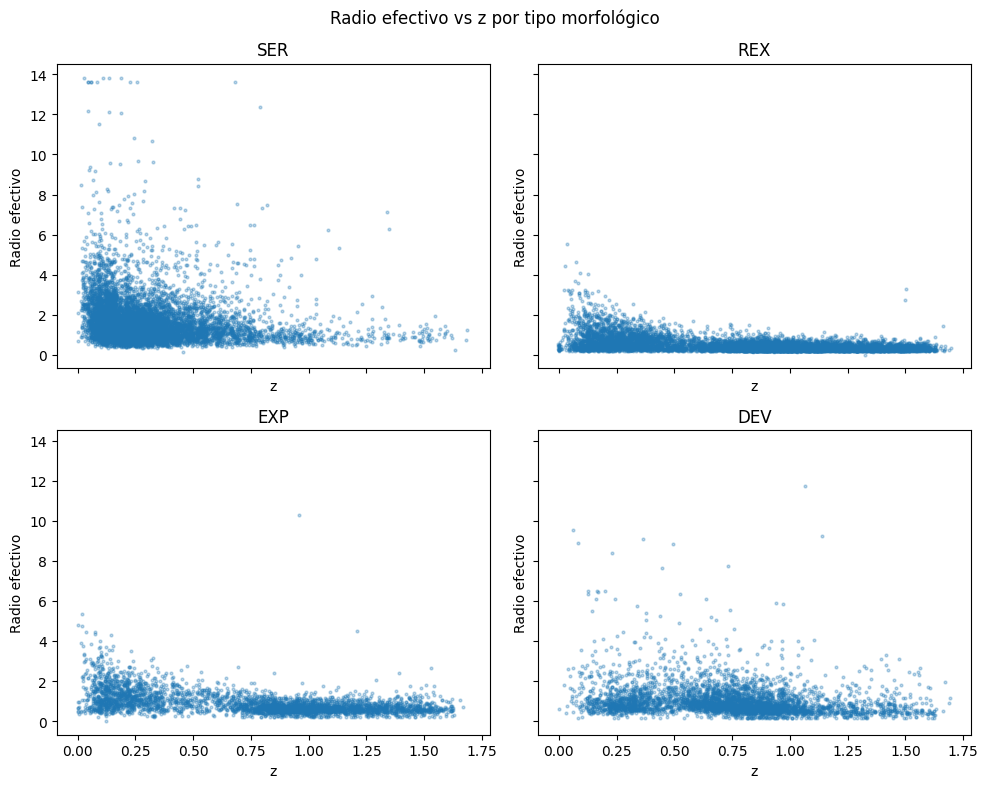

'\n- Se logra ver que las galaxias REX que presentan un mayor shape_r,\nse encuentran a redshift bajo.\n- Las galaxias espirales, hay algunos casos que presentan shape_r alto\n    a redshift mayores.\n\n'

In [29]:
### DISTRIBUCIÓN DE Z VS SHAPE_R
### AHORA LO VAMOS A SEPARAR POR TIPO
types = df_cosmos["type"].unique().tolist()

## SUBPLOTS 
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, t in zip(axes.flat, types):
    df_temp = df_features_images[df_features_images["type"] == t]
    ax.plot(df_temp["z"], df_temp["shape_r"], "o", ms=2, alpha=0.3)
    ax.set_title(t)
    ax.set_xlabel("z")
    ax.set_ylabel("Radio efectivo")
fig.suptitle("Radio efectivo vs z por tipo morfológico")
plt.tight_layout()
plt.show()
"""
- Se logra ver que las galaxias REX que presentan un mayor shape_r,
se encuentran a redshift bajo.
- Las galaxias espirales, hay algunos casos que presentan shape_r alto
    a redshift mayores.

"""

df_cosmos:
type
REX    226865
SER    195397
DEV     94628
EXP     84724
Name: count, dtype: int64

df_features_images:
type
REX    9893
SER    8654
DEV    4016
EXP    3603
Name: count, dtype: int64


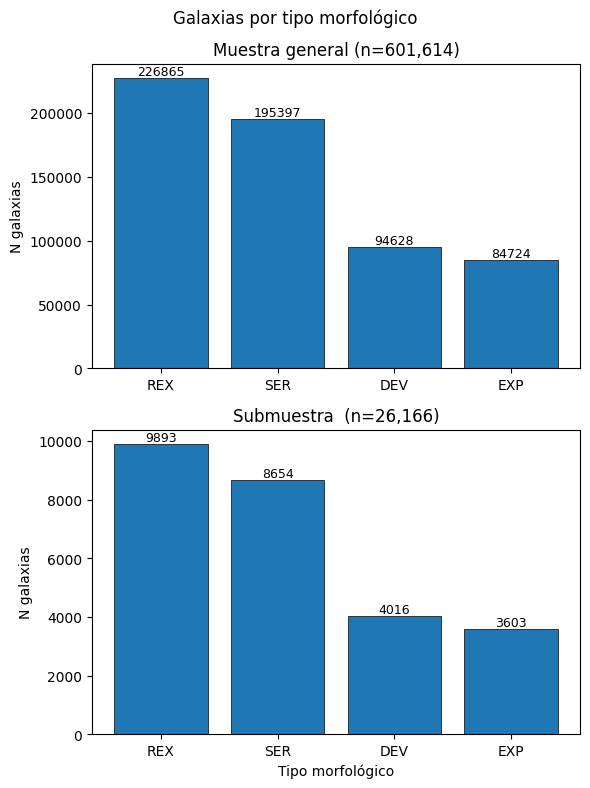

In [34]:
#######################################
# 1. Cuántas galaxias de cada tipo hay?

counts_cosmos   = df_cosmos["type"].value_counts()
counts_features = df_features_images["type"].value_counts()

print("df_cosmos:")
print(counts_cosmos)
print("\ndf_features_images:")
print(counts_features)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

ax1.bar(counts_cosmos.index, counts_cosmos.values, edgecolor="k", linewidth=0.5)
ax1.set_title(f"Muestra general (n={len(df_cosmos):,})")
# ax1.set_xlabel("Tipo morfológico")
ax1.set_ylabel("N galaxias")
for i, v in enumerate(counts_cosmos.values):
    ax1.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

ax2.bar(counts_features.index, counts_features.values, edgecolor="k", linewidth=0.5)
ax2.set_title(f"Submuestra  (n={len(df_features_images):,})")
ax2.set_xlabel("Tipo morfológico")
ax2.set_ylabel("N galaxias")
for i, v in enumerate(counts_features.values):
    ax2.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

plt.suptitle("Galaxias por tipo morfológico")
plt.tight_layout()
plt.show()

In [25]:
############# CALCULO AREA ELIPSE
# 2. Área de la elipse en arcsec^2
#
# shape_r  : radio de media-luz [arcsec] (eje mayor)
# shape_e1, shape_e2 : componentes de elipticidad
#
# Magnitud de la elipticidad total:
#   e = sqrt(e1^2 + e2^2)
#
# Razón de ejes b/a a partir de la elipticidad:
#   q = b/a = sqrt((1 - e) / (1 + e))
#
# Área de la elipse (pi * a * b = pi * r * r*q):
#   área = pi * shape_r^2 * q   [arcsec^2]

def ellipse_area(df):
    e = np.sqrt(df["shape_e1"]**2 + df["shape_e2"]**2).clip(0, 0.9999)
    q = np.sqrt((1 - e) / (1 + e))
    return np.pi * df["shape_r"]**2 * q

df_cosmos["ellipse_area_arcsec2"]          = ellipse_area(df_cosmos)
df_features_images["ellipse_area_arcsec2"] = ellipse_area(df_features_images)

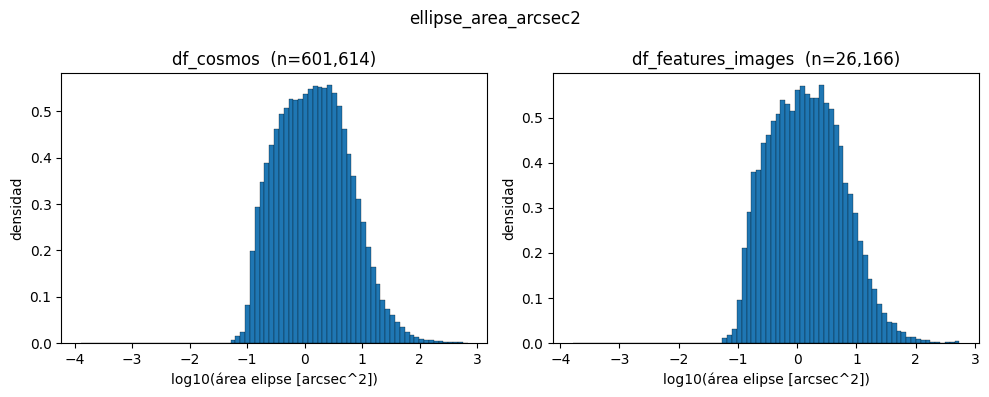

In [26]:
compare_dist("ellipse_area_arcsec2", bins=80, log_x=True,
             xlabel="log10(área elipse [arcsec^2])", plot_type="histogram")

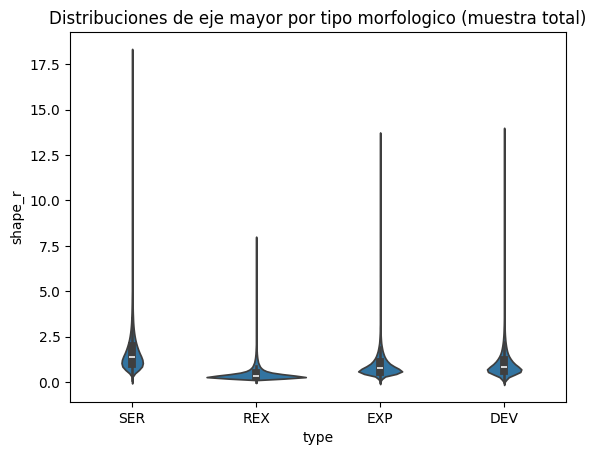

In [27]:
##################################

### distribuciones de area por tipo de galaxia: shape_r = EJE MAYOR
plt.figure()
plt.title(f"Distribuciones de eje mayor por tipo morfologico (muestra total)")
sns.violinplot(data=df_cosmos, x="type", y="shape_r")
plt.show()
# hacer print de los cuartiles por tipo morfologico de la muestra total

In [27]:
types = df_cosmos["type"].unique().tolist()

for i in types:
    df_temp = df_cosmos[df_cosmos["type"]==i]
    print(f" Estadísticas de shape_r del tipo {i} \n {df_temp["shape_r"].describe()}")

"""
Lo que llama la atención es que galaxias tipo REX son galaxias circulares
(casi clasifican como PSF), entonces no puedo delucidar si es irreal que
una galaxia tipo REX registre valores tan altos en su eje mayor.
Se esperaria que las galaxias REX estén a una distancia próxima.
"""

 Estadísticas de shape_r del tipo SER 
 count    208902.000000
mean          1.800593
std           1.476750
min           0.139330
25%           1.003267
50%           1.413932
75%           2.076226
max          63.758396
Name: shape_r, dtype: float64
 Estadísticas de shape_r del tipo REX 
 count    240584.000000
mean          0.469741
std           0.371632
min           0.010000
25%           0.272153
50%           0.362445
75%           0.519742
max          36.630817
Name: shape_r, dtype: float64
 Estadísticas de shape_r del tipo EXP 
 count    90670.000000
mean         0.939873
std          0.664050
min          0.010000
25%          0.567019
50%          0.766895
75%          1.114230
max         29.793400
Name: shape_r, dtype: float64
 Estadísticas de shape_r del tipo DEV 
 count    101281.000000
mean          1.094934
std           0.987413
min           0.010000
25%           0.598764
50%           0.845249
75%           1.265753
max          33.516730
Name: shape_r, dtype: 

'\nLo que llama la atención es que galaxias tipo REX son galaxias circulares\n(casi clasifican como PSF), entonces no puedo delucidar si es irreal que\nuna galaxia tipo REX registre valores tan altos en su eje mayor.\nSe esperaria que las galaxias REX estén a una distancia próxima.\n'

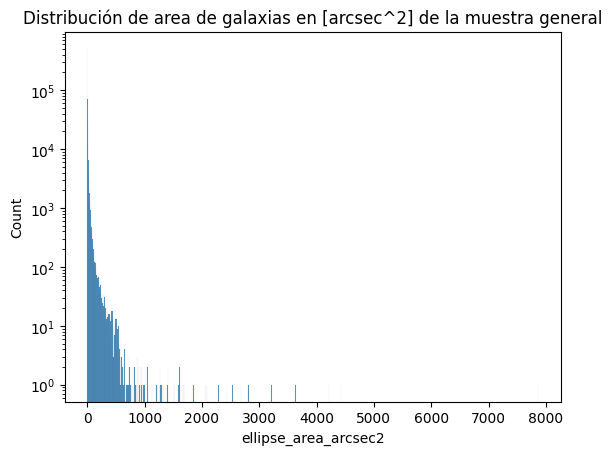


 Estadísticas de area elipse del tipo SER 
 count    208902.000000
mean         12.232552
std          46.355343
min           0.023537
25%           2.312916
50%           4.502452
75%           9.671236
max        7863.340060
Name: ellipse_area_arcsec2, dtype: float64

 Estadísticas de area elipse del tipo REX 
 count    240584.000000
mean          1.127099
std           9.862935
min           0.000314
25%           0.232690
50%           0.412700
75%           0.848642
max        4215.441657
Name: ellipse_area_arcsec2, dtype: float64

 Estadísticas de area elipse del tipo EXP 
 count    90670.000000
mean         2.709571
std         10.668751
min          0.000127
25%          0.691323
50%          1.273011
75%          2.640743
max       1608.867181
Name: ellipse_area_arcsec2, dtype: float64

 Estadísticas de area elipse del tipo DEV 
 count    101281.000000
mean          5.055533
std          23.053061
min           0.000158
25%           0.868980
50%           1.776340
75%      

In [28]:
plt.figure()
plt.title(f"Distribución de area de galaxias en [arcsec^2] de la muestra general")
sns.histplot(data=df_cosmos, x="ellipse_area_arcsec2")
plt.yscale("log")
plt.show()
# printear cuantas galaxias superan el 3 cuartil

for i in types:
    df_temp = df_cosmos[df_cosmos["type"]==i]
    print(f"\n Estadísticas de area elipse del tipo {i} \n {df_temp["ellipse_area_arcsec2"].describe()}")

In [29]:

##### Ver outliers con el rango intercuatilico
print(f"Outliers de áreas de la elipse")
for i in types:
    s = df_cosmos.loc[df_cosmos["type"] == i, "ellipse_area_arcsec2"]
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    outliers = s[(s < lower) | (s > upper)]
    print(f"\n{i}: {len(s)} total, {len(outliers)} outliers ({100*len(outliers)/len(s):.1f}%)")
    print(f"IQR: [{Q1:.2f}, {Q3:.2f}], bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"Outlier range: [{outliers.min():.2f}, {outliers.max():.2f}]")
"""
Se identifican la cantidad de galaxias que son outliers en cuanto
al area de la elipse. Queda la duda si deben eliminarse o no.
"""

Outliers de áreas de la elipse

SER: 208902 total, 22250 outliers (10.7%)
IQR: [2.31, 9.67], bounds: [-8.72, 20.71]
Outlier range: [20.71, 7863.34]

REX: 240584 total, 29097 outliers (12.1%)
IQR: [0.23, 0.85], bounds: [-0.69, 1.77]
Outlier range: [1.77, 4215.44]

EXP: 90670 total, 8422 outliers (9.3%)
IQR: [0.69, 2.64], bounds: [-2.23, 5.56]
Outlier range: [5.57, 1608.87]

DEV: 101281 total, 10211 outliers (10.1%)
IQR: [0.87, 3.92], bounds: [-3.70, 8.48]
Outlier range: [8.48, 2432.81]


'\nSe identifican la cantidad de galaxias que son outliers en cuanto\nal area de la elipse. Queda la duda si deben eliminarse o no.\n'

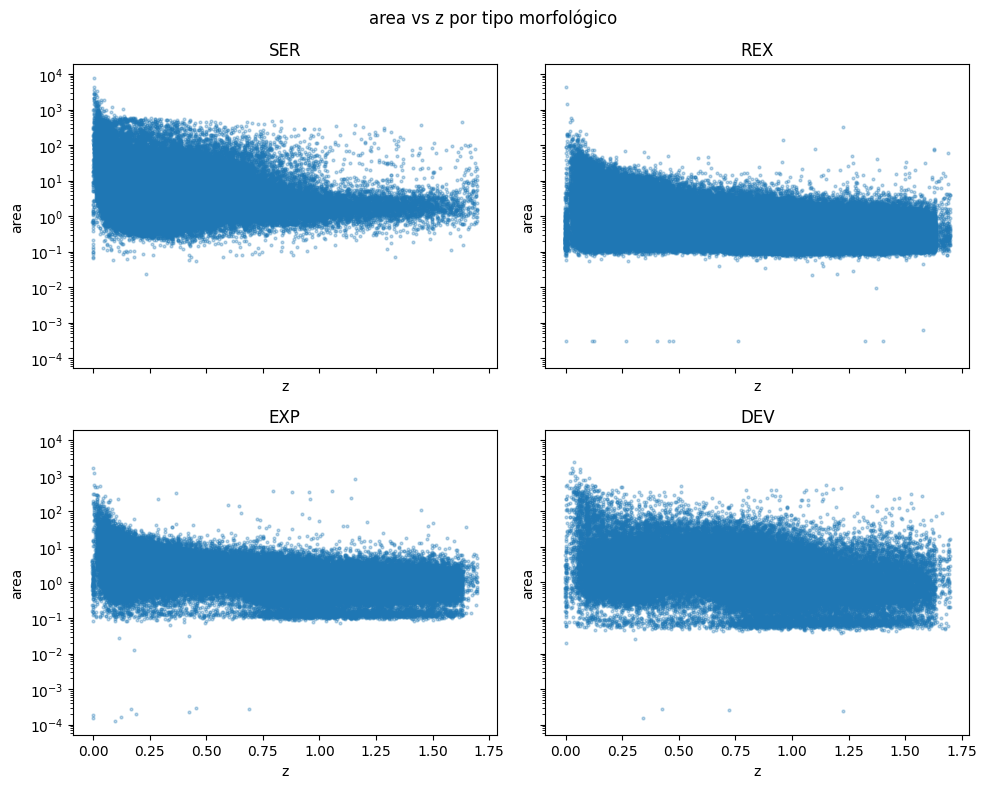

In [30]:
### Z vs AREA
## SUBPLOTS 
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, t in zip(axes.flat, types):
    df_temp = df_cosmos[df_cosmos["type"] == t]
    ax.plot(df_temp["z"], df_temp["ellipse_area_arcsec2"], "o", ms=2, alpha=0.3)
    ax.set_title(t)
    ax.set_xlabel("z")
    ax.set_ylabel("area")
fig.suptitle("area vs z por tipo morfológico")
plt.tight_layout()
plt.yscale("log")
plt.show()

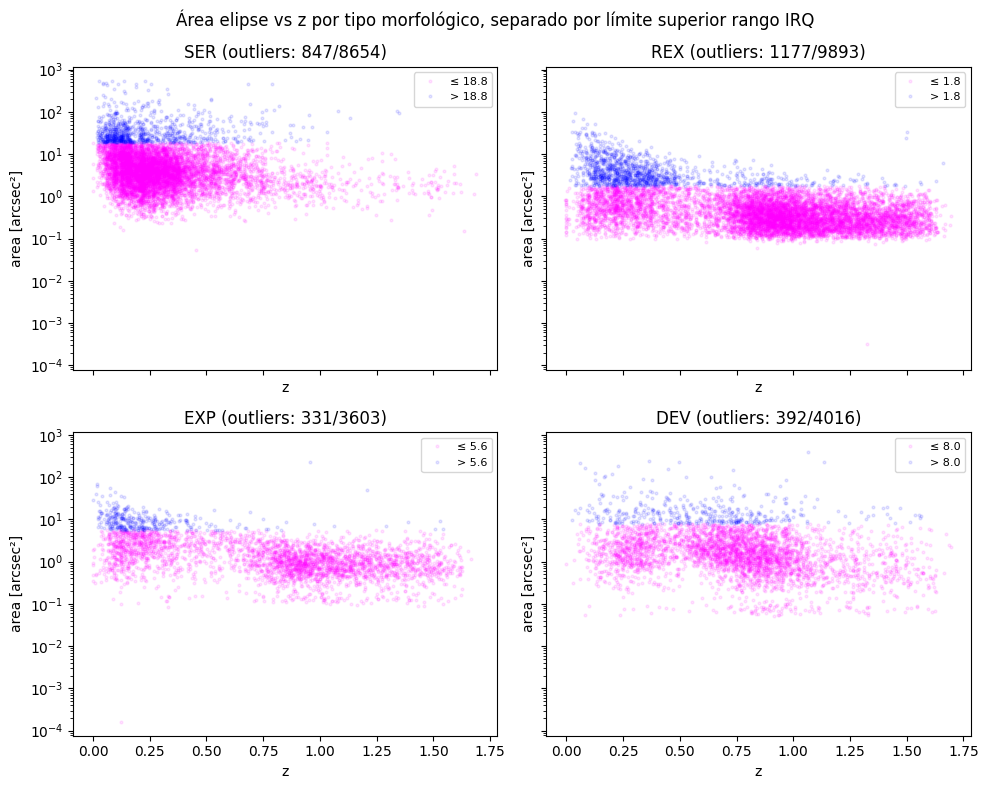

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, t in zip(axes.flat, types):
    df_t = df_features_images[df_features_images["type"] == t]
    area = df_t["ellipse_area_arcsec2"]
    
    Q1, Q3 = area.quantile(0.25), area.quantile(0.75)
    upper = Q3 + 1.5 * (Q3 - Q1)
    
    normal = df_t[area <= upper]
    outlier = df_t[area > upper]
    
    ax.plot(normal["z"], normal["ellipse_area_arcsec2"], "o", ms=2, alpha=0.1, color="magenta", label=f"≤ {upper:.1f}")
    ax.plot(outlier["z"], outlier["ellipse_area_arcsec2"], "o", ms=2, alpha=0.1, color="blue", label=f"> {upper:.1f}")
    ax.set_title(f"{t} (outliers: {outlier.shape[0]}/{df_t.shape[0]})")
    ax.set_xlabel("z")
    ax.set_ylabel("area [arcsec²]")
    plt.yscale("log")
    ax.legend(fontsize=8)

fig.suptitle("Área elipse vs z por tipo morfológico, separado por límite superior rango IRQ")
plt.tight_layout()
plt.show()

In [36]:
## ¿Cuántas galaxias tienen r_shape mayor a 20''?
df_temp = df_features_images[df_features_images["shape_r"] > 20]
print(f" Cantidad de galaxias que tienen shape_r mayor a 20'': {df_temp.shape[0]}")

df_temp["type"].value_counts()



 Cantidad de galaxias que tienen shape_r mayor a 20'': 0


Series([], Name: count, dtype: int64)

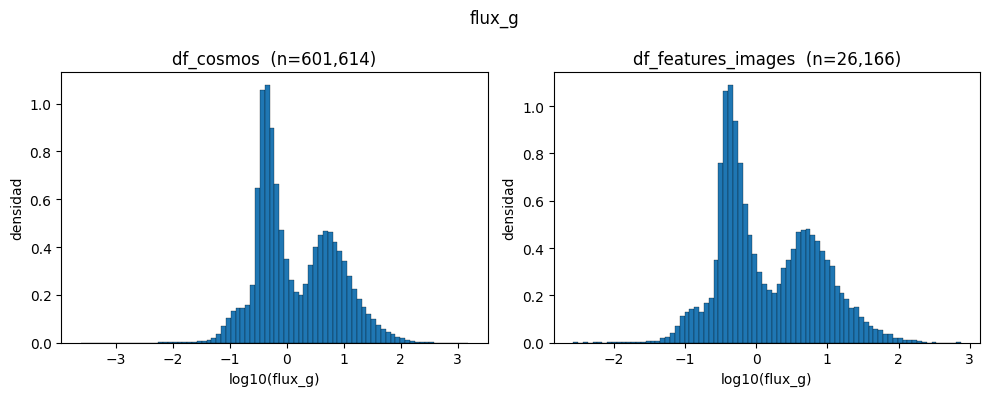

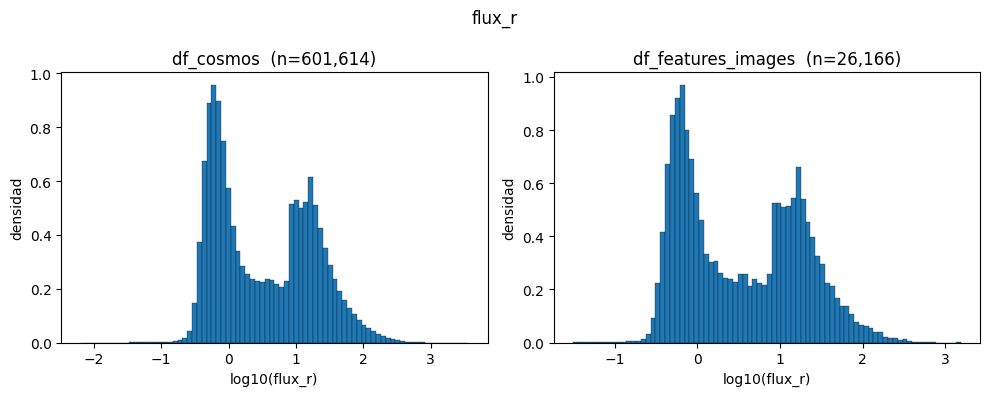

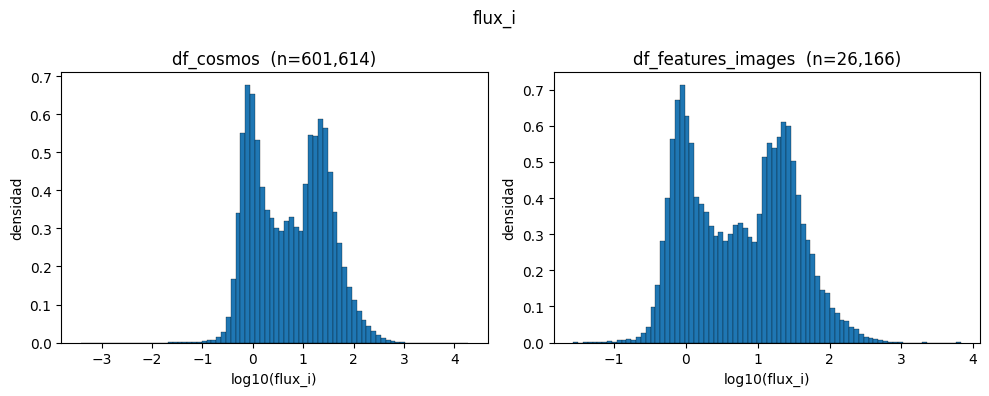

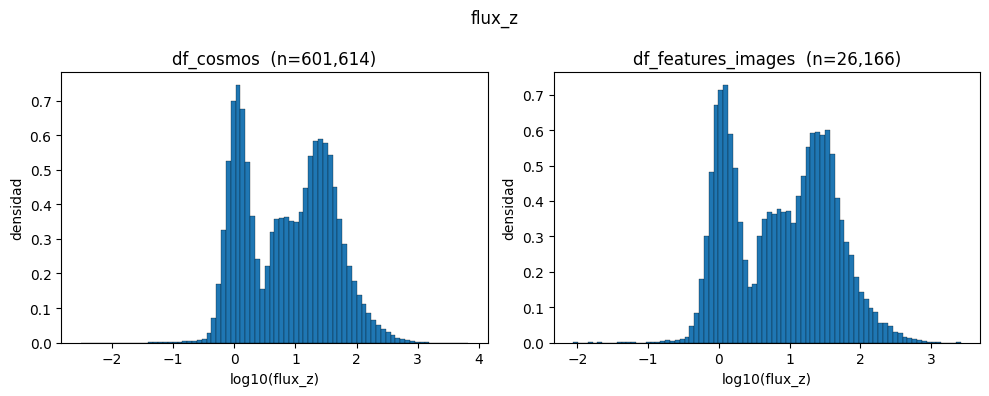

In [37]:
################### FLUJOS 
############### Lo que se busca acá es estudiar 
############## la distribución de los flujos declarados en el catálogo fotométrico.

# Flujos por banda (log scale)

flux_cols = ["flux_g", "flux_r", "flux_i", "flux_z"]
# flux_cols = [

#     c for c in df_cosmos.columns
#     if re.fullmatch(r"flux_\w{1,2}", c) and c in df_features_images.columns
# ]
# print(f"Columnas de flujo: {flux_cols}")

for col in flux_cols:
    compare_dist(col, bins=80, log_x=True)

In [38]:
# Fracción de flujos negativos o nulos por banda
neg_frac = pd.DataFrame({
    "df_cosmos":          [(df_cosmos[c] <= 0).mean() for c in flux_cols],
    "df_features_images": [(df_features_images[c] <= 0).mean() for c in flux_cols],
}, index=flux_cols).round(4)
print(neg_frac)

        df_cosmos  df_features_images
flux_g     0.0007                 0.0
flux_r     0.0001                 0.0
flux_i     0.1640                 0.0
flux_z     0.0002                 0.0


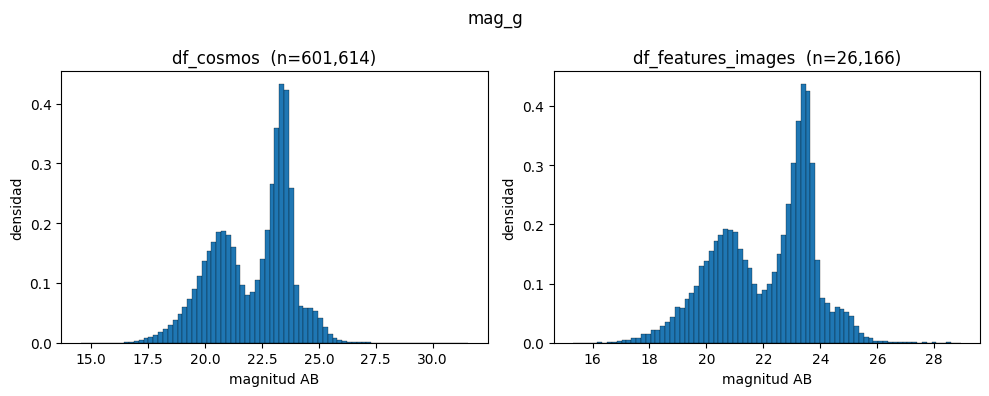

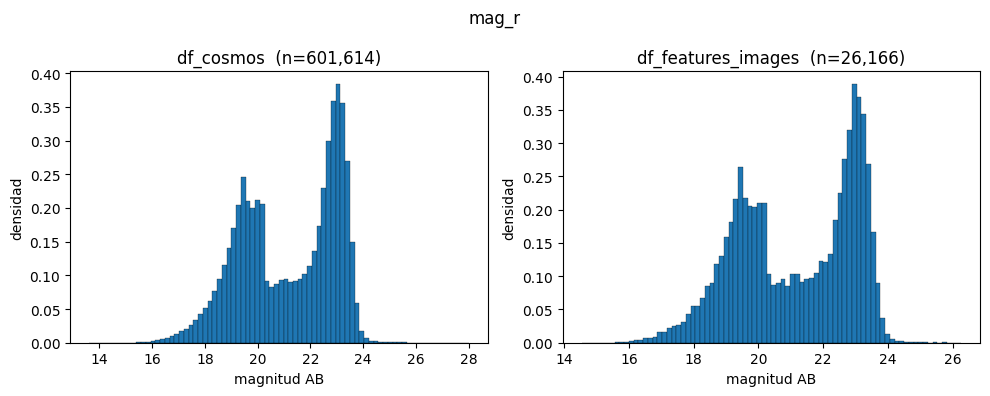

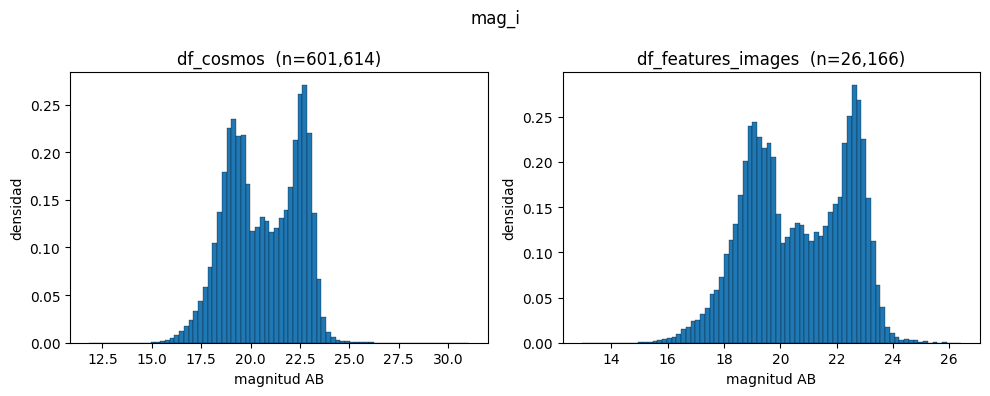

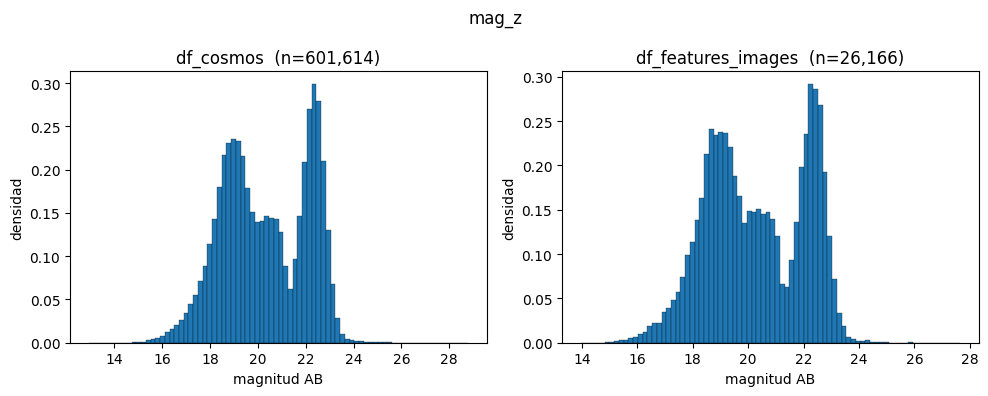

'\n- Según una referencia en donde se predice el redshift\n    descartaron galaxias out of range g mayor a 24.0,\n    r mayor a 23.4, z mayor a 22.5.\n- Otra cosa que no he considerado ahora es la cantidad\n    de fuentes que tiene el parámetro maskbits distinto de 0.\n'

In [ ]:
# Magnitudes AB (solo flujo > 0)
# SEGUN EL CATÁLOGO, LOS FLUJOS YA ESTÁN EN EL SISTEMA AB
# POR LO QUE AL PASARLO A M, ES DIRECTO CON LA FORMULA

def flux_to_mag(flux_series):
    pos = flux_series.copy().astype(float)
    pos[pos <= 0] = np.nan
    return 22.5 - 2.5 * np.log10(pos)

for col in flux_cols:
    mag_col = col.replace("flux_", "mag_")
    df_cosmos[mag_col] = flux_to_mag(df_cosmos[col])
    df_features_images[mag_col] = flux_to_mag(df_features_images[col])
    compare_dist(mag_col, bins=80, xlabel="magnitud AB")



    DEBERÍAN DESCARTARSE ENTONCES ESTAS GALAXIAS: de acuerdo a la referencia, 
    - We also delete all galaxies with maskbits! = 0,
    because these sources are either in corrupted imaging pixels, or
    pixels that in the vicinity of bright stars, globular clusters, or
    nearby galaxies.-
    
    - DUDA: me entra duda sobre descartar fuentes debiles en las 4 bandas.

## mwTRANSMISSION

Sobre los coeficientes de extinción galáctica:
- Estos son derivados de SFD98maps, pero con coeficientes atualizados para
    convertir E(B-V) a la extinción en cada filtro. 
- Los coeficientes son reportados en unidades lineales de transmisión
    con:
    - 1  representa una región totalmente transparente de la via lactea
    - 0 representa una región totalmente opaca.
- Eddie Schalffly calculó los coefcientes de extinción para los
    filtros de DECam : A_\lambda /E(B-V) = R_\lambda
```

    { 
    "u": 3.995,
    "g": 3.214,
    "r": 2.165,
    "i": 1.592,
    "z": 1.211,
    "Y": 1.064
    }
    Los coeficientes son multiplicados por el valor de SFD98 E(B-V)
    en las coordenadas de cada objeto para derivar mw_transmission para
    las bandas grz.

    Se calcula la extinción galáctica para BASS y MzLS como si estuvieran 
    en sistema de filtros.
```

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\_'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_105437/3802929350.py:12: SyntaxWarning: invalid escape sequence '\l'
  filtros de DECam : A_\lambda /E(B-V) = R_\lambda
/tmp/ipykernel_105437/3802929350.py:50: SyntaxWarning: invalid escape sequence '\_'
  T\_lambda = 10^{-0.4 R\_lambda* E(B-V)}


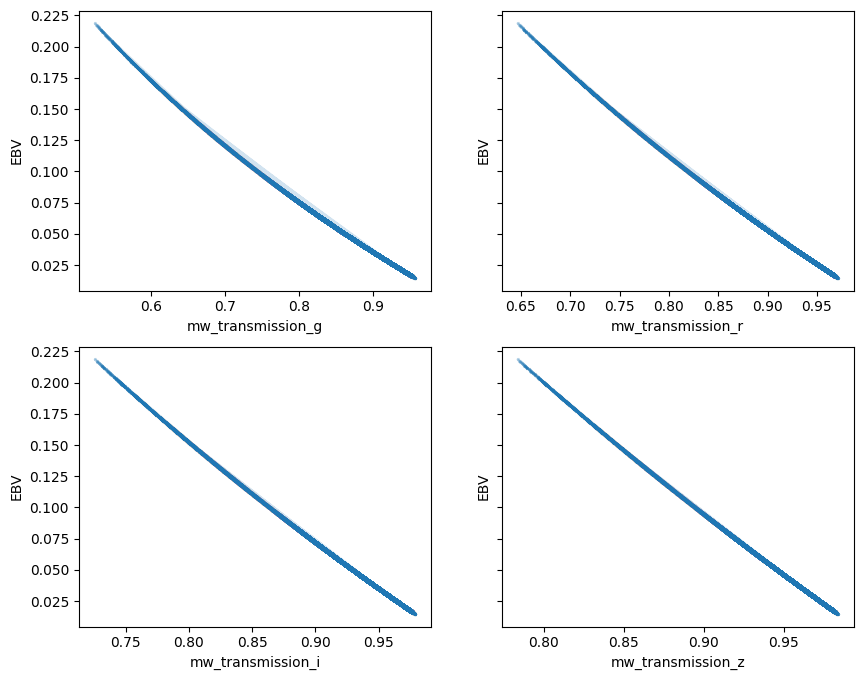

'\nSon inversamente proporcionales porque el cociente mw_transmission\nque entrega el catálogo es\n\nT\\_lambda = 10^{-0.4 R\\_lambda* E(B-V)}\n\nEso explica la relación inversamente proporcional.\n'

In [37]:
## mwTRANSMISSION

"""
Sobre los coeficientes de extinción galáctica:
- Estos son derivados de SFD98maps, pero con coeficientes atualizados para
    convertir E(B-V) a la extinción en cada filtro. 
- Los coeficientes son reportados en unidades lineales de transmisión
    con:
    - 1  representa una región totalmente transparente de la via lactea
    - 0 representa una región totalmente opaca.
- Eddie Schalffly calculó los coefcientes de extinción para los
    filtros de DECam : A_\lambda /E(B-V) = R_\lambda

    { 
    "u": 3.995,
    "g": 3.214,
    "r": 2.165,
    "i": 1.592,
    "z": 1.211,
    "Y": 1.064
    }
    Los coeficientes son multiplicados por el valor de SFD98 E(B-V)
    en las coordenadas de cada objeto para derivar mw_transmission para
    las bandas grz.

    Se calcula la extinción galáctica para BASS y MzLS como si estuvieran 
    en sistema de filtros.

"""

cols = ["mw_transmission_g", "mw_transmission_r", "mw_transmission_i", "mw_transmission_z"]
df_cosmos[cols].describe()
#### LO QUE HAY QUE ENTENDER ES POR QUE SE RELACIONAN DE MANERA NEGATIVA
##### CON EBV 

fig, axes= plt.subplots(2,2, figsize=(10,8), sharey = True, sharex=False)

for ax, col in zip(axes.flat, cols):
    x = df_cosmos[col]
    y = df_cosmos["ebv"]
    ax.plot(x, y, marker="*", ms=2, alpha=0.2)
    ax.set_xlabel(f"{col}")
    ax.set_ylabel("EBV")
plt.show()

"""
Son inversamente proporcionales porque el cociente mw_transmission
que entrega el catálogo es

T\_lambda = 10^{-0.4 R\_lambda* E(B-V)}

Eso explica la relación inversamente proporcional.
"""

In [38]:
### Para finalizar, comprobamos que las columnas mw_transmission corresponde a el cociente calculado a mano
### Según la fórmula de arriba.

# probamos con la banda g primero y luego i

df_features_images["wm_ti"] = 10**(-0.4 * 1.592 * df_features_images["ebv"])

In [39]:
df_features_images[["wm_ti", "mw_transmission_i"]].describe()

,wm_ti,mw_transmission_i
count,27757.000000,27757.000000
mean,0.941768,0.941768
std,0.025852,0.025852
min,0.728906,0.728906
25%,0.932831,0.932832
50%,0.946041,0.946041
75%,0.958208,0.958208
max,0.978230,0.978231


In [40]:
df_features_images[["wm_ti", "mw_transmission_i"]]

,wm_ti,mw_transmission_i
0,0.925850,0.925850
1,0.936748,0.936748
2,0.941889,0.941889
3,0.938758,0.938758
4,0.930453,0.930453
...,...,...
29570,0.972437,0.972437
29571,0.949327,0.949327
29572,0.933687,0.933687
29573,0.946293,0.946293


**Comentarios** Son iguales.

In [41]:
##### ALGUNAS ESTADISTICAS DE LOS STAMPS

"""
- Sobre los stamps:
    - 1. Ver cuántos de ellos presentan valores nulos:
        Por nivel de resolución y por banda.
    - Ver distribución de los flujos? promedio, std, mediana,...
        Esto no me queda claro si es por stamp o que onda
"""


'\n- Sobre los stamps:\n    - 1. Ver cuántos de ellos presentan valores nulos:\n        Por nivel de resolución y por banda.\n    - Ver distribución de los flujos? promedio, std, mediana,...\n        Esto no me queda claro si es por stamp o que onda\n'

In [42]:
"""
Los arrays representan matrices.
- Se tienen 4 bandas
- cada banda tiene 5 niveles de resolucion

Partamos con un análisis por banda: griz

- array[i] --- Se accede a info de objeto i. i \in [0, 32,921]
- array[i][j] --- Se accede a info de banda j de un objeto i. j -[0,1,2,3], 
    {
    j ; band
    --------
    0: banda g, 
    1: banda r, 
    2: banda i,
    3: banda z, 
    }

- array[i][j][k] --- Se accede a info de objeto i, banda j, resolución k
    {
    k; level
    --------
    0: nivel 1 (FOV 7.5'' -- alta resolución, se ve menos estructura)
    1: nivel 2 (FOV 15'')
    2: nivel 3 (FOV 30'')
    3: nivel 4 (FOV 60'')
    4: nivel 5 (FOV 120'' ---- baja resolución, se ve más estructura)
    }
"""

<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_105437/2874015958.py:8: SyntaxWarning: invalid escape sequence '\i'
  - array[i] --- Se accede a info de objeto i. i \in [0, 32,921]


"\nLos arrays representan matrices.\n- Se tienen 4 bandas\n- cada banda tiene 5 niveles de resolucion\n\nPartamos con un análisis por banda: griz\n\n- array[i] --- Se accede a info de objeto i. i \\in [0, 32,921]\n- array[i][j] --- Se accede a info de banda j de un objeto i. j -[0,1,2,3], \n    {\n    j ; band\n    --------\n    0: banda g, \n    1: banda r, \n    2: banda i,\n    3: banda z, \n    }\n\n- array[i][j][k] --- Se accede a info de objeto i, banda j, resolución k\n    {\n    k; level\n    --------\n    0: nivel 1 (FOV 7.5'' -- alta resolución, se ve menos estructura)\n    1: nivel 2 (FOV 15'')\n    2: nivel 3 (FOV 30'')\n    3: nivel 4 (FOV 60'')\n    4: nivel 5 (FOV 120'' ---- baja resolución, se ve más estructura)\n    }\n"

In [40]:
## Veamos qué/cuántos stamps tiene valores nulos

BAND_NAMES  = {0: "g", 1: "r", 2: "i", 3: "z"}
LEVEL_NAMES = {0: "nivel_1", 1: "nivel_2", 2: "nivel_3", 3: "nivel_4", 4: "nivel_5"}

rows = []
for i, stamp in enumerate(arrays):
    for j, band_name in BAND_NAMES.items():
        row = {"id_stamp": names[i], "band": band_name}
        for k, level_name in LEVEL_NAMES.items():
            row[level_name] = int(np.isnan(stamp[j][k]).sum())
        rows.append(row)

df_nulls = pd.DataFrame(rows)
print(df_nulls)

                 id_stamp band  nivel_1  nivel_2  nivel_3  nivel_4  nivel_5
0       39627902047750789    g        0        0        0        0        0
1       39627902047750789    r        0        0        0        0        0
2       39627902047750789    i        0        0        0        0        0
3       39627902047750789    z        0        0        0        0        0
4       39627690600301000    g        0        0        0        0        0
...                   ...  ...      ...      ...      ...      ...      ...
131679  39627841515557783    z        0        0        0        0        0
131680  39627865821546218    g        0        0        0        0        0
131681  39627865821546218    r        0        0        0        0        0
131682  39627865821546218    i        0        0        0        0        0
131683  39627865821546218    z        0        0        0        0        0

[131684 rows x 7 columns]


In [41]:
##3 Se identifican los stamps que presentan valores nulos
df_stamps_problematicos = df_nulls.query("nivel_1 > 0 or nivel_2 > 0 or nivel_3 > 0 or nivel_4 > 0 or nivel_5 > 0").copy()

In [42]:
df_stamps_problematicos

,id_stamp,band,nivel_1,nivel_2,nivel_3,nivel_4,nivel_5
3650,39627769163813429,i,0,0,0,155,300
4054,39627763119820151,i,900,738,593,510,478
5342,39627666529194708,i,0,0,0,0,34
6454,39627769084118131,i,0,100,270,343,390
7856,39628075318643463,g,900,0,0,0,0
...,...,...,...,...,...,...,...
112634,39627624460320813,i,0,0,0,11,214
113774,39627684514365602,i,780,600,516,480,450
124046,39627654491543166,i,0,0,0,30,240
128446,39627823572320346,i,0,0,0,0,162


In [55]:
###
########## FUNCIÓN PARA VISUALIZAR LOS PLOTS

BAND_LABELS = ["g", "r", "i", "z"]

FOV_LEVELS = ["7.5''", "15''", "30''", "60''", "120''"]


N_LEVELS = 5

def normalise(img):
    vmin, vmax = np.nanpercentile(img, [1, 99])
    return np.clip((img - vmin) / (vmax - vmin + 1e-10), 0, 1)

def plot_galaxy(arr, name, band_labels=BAND_LABELS, n_levels=N_LEVELS, save_path=None):
    """
    Plot one galaxy: rows = resolution levels, columns = bands.
    arr shape: (B, 5, 30, 30)
    """
    n_bands = arr.shape[0]
    labels = band_labels[:n_bands]

    fig, axes = plt.subplots(n_bands, n_levels, figsize=(n_levels * 2.5, n_bands * 2.5))
    fig.suptitle(f"Galaxy {name} - {n_bands} bands x {n_levels} resolution levels", fontsize=12)

    for row in range(n_bands):
        for col in range(n_levels):
            ax = axes[row, col]
            ax.imshow(normalise(arr[row, col]), origin="lower", cmap="gray")
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title("FOV: " + FOV_LEVELS[col], fontsize=10)
        axes[row, 0].set_ylabel(labels[row], fontsize=16, rotation=0, labelpad=30, va="center")
    plt.tight_layout()
    plt.show()

#### Para probar la función: 
## 1. vamos a rescatar los indices de los objetos
## que presentan problemas de nan

idx_obj_prob = []

for i in df_stamps_problematicos["id_stamp"].unique(): # recorre los ids de los stamps
    w = names.index(i)
    idx_obj_prob.append(w)

In [57]:
df_features_images

,desi_id,mean_fiber_ra,mean_fiber_dec,z,zerr,ra,dec,type,shape_r,shape_e1,...,mw_transmission_w2,mw_transmission_w3,objid,mw_transmission_w4,mw_transmission_r,ellipse_area_arcsec2,mag_g,mag_r,mag_i,mag_z
0,39627636401508885,147.028920,-6.291707,0.863852,0.000078,147.028933,-6.291716,REX,1.202857,0.000000,...,0.994546,0.998834,9672,0.999560,0.900529,4.545463,22.324675,21.485594,20.529676,20.054061
1,39627654457984508,147.941447,-5.506874,1.160004,0.000053,147.941456,-5.506887,EXP,0.358474,-0.312599,...,0.995373,0.999011,3484,0.999627,0.914975,0.280631,24.167213,24.281325,25.497515,23.827991
2,39627720786707922,148.820687,-2.767029,0.333578,0.000005,148.820681,-2.767036,REX,0.305442,0.000000,...,0.995760,0.999094,1595,0.999658,0.921810,0.293095,23.228341,22.839969,22.542008,22.023038
3,39627660615225397,156.331311,-5.158549,0.159566,0.000016,156.331327,-5.158570,SER,0.509001,-0.049165,...,0.995524,0.999044,7945,0.999639,0.917645,0.700552,19.997332,19.194921,18.868675,18.663368
4,39627678684283452,156.207028,-4.541228,0.864645,0.000132,156.207011,-4.541233,REX,0.279362,0.000000,...,0.994897,0.998909,1152,0.999588,0.906623,0.245181,25.376636,23.249963,21.819916,21.203246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29570,39627968078679914,151.770335,7.574563,0.125753,0.000014,151.770339,7.574556,EXP,0.748664,0.079242,...,0.998018,0.999577,5444,0.999840,0.962703,1.263122,22.831288,22.425976,22.258516,21.895141
29571,39627805423568301,153.560091,0.738629,0.981242,0.000049,153.560079,0.738607,REX,0.830543,0.000000,...,0.996316,0.999213,3722,0.999703,0.931724,2.167075,22.734677,22.438681,21.989507,21.667859
29572,39627841737851674,158.033419,2.225420,0.905659,0.000019,158.033423,2.225414,REX,0.405263,0.000000,...,0.995142,0.998962,850,0.999608,0.910911,0.515968,22.806673,22.515903,22.117945,21.918312
29573,39627889993320651,156.590201,4.210283,0.073323,0.000003,156.590189,4.210277,SER,1.827961,-0.169518,...,0.996089,0.999165,2705,0.999684,0.927677,8.509218,18.602760,18.101706,17.882311,17.737412


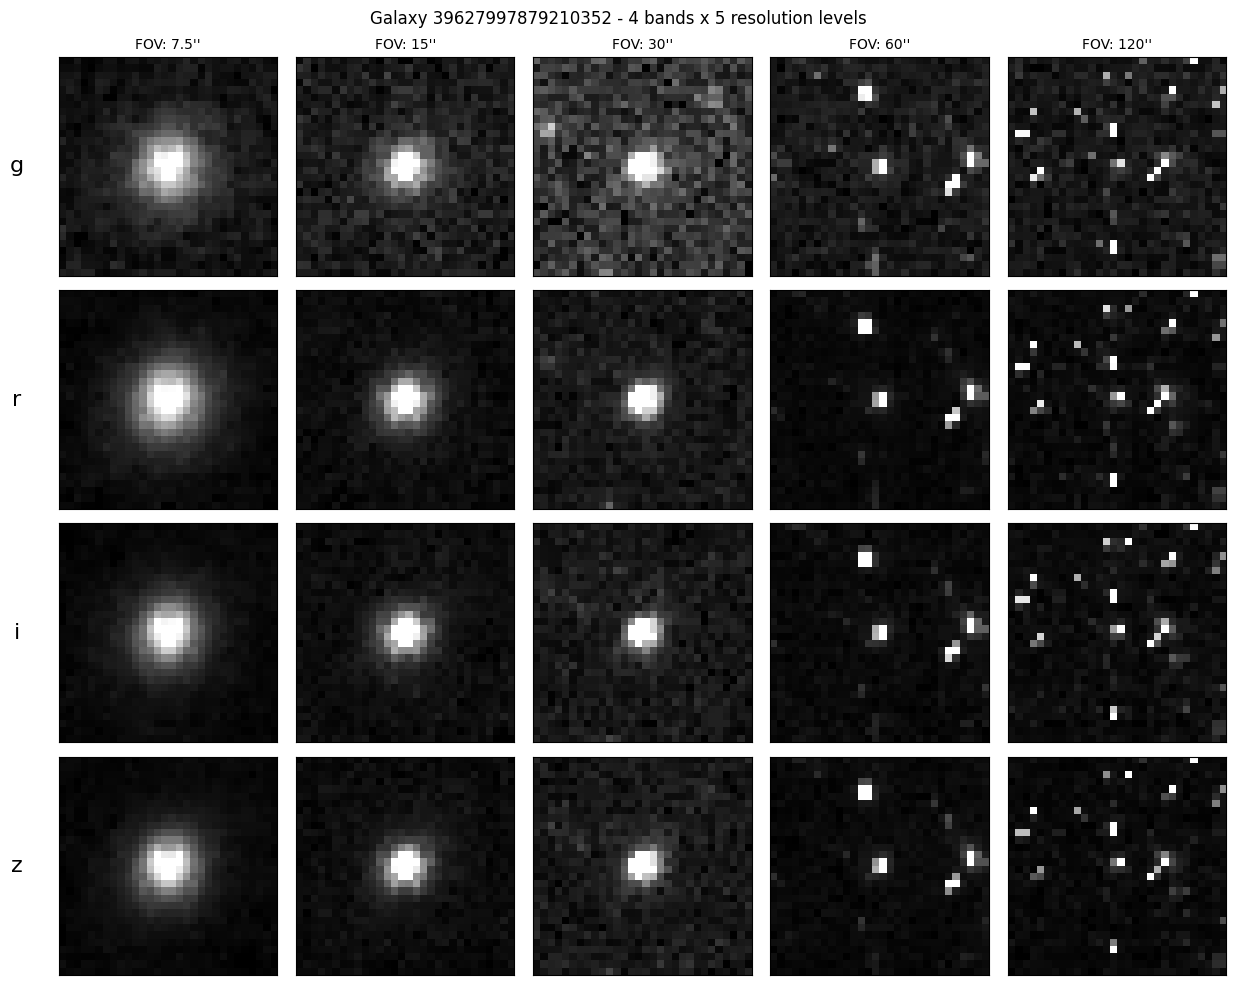

In [63]:
plot_galaxy(arrays[2], names[2])

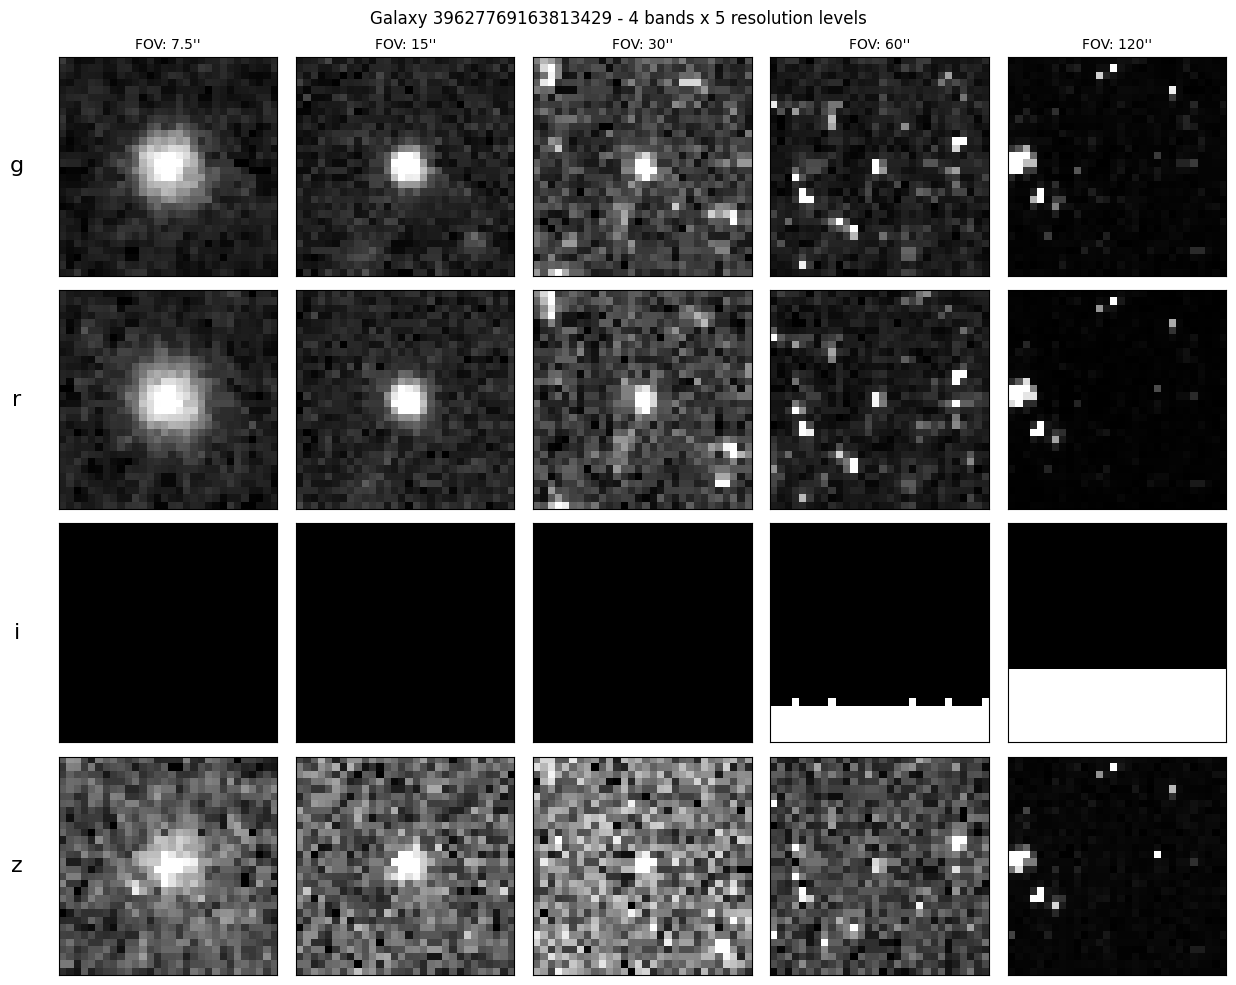

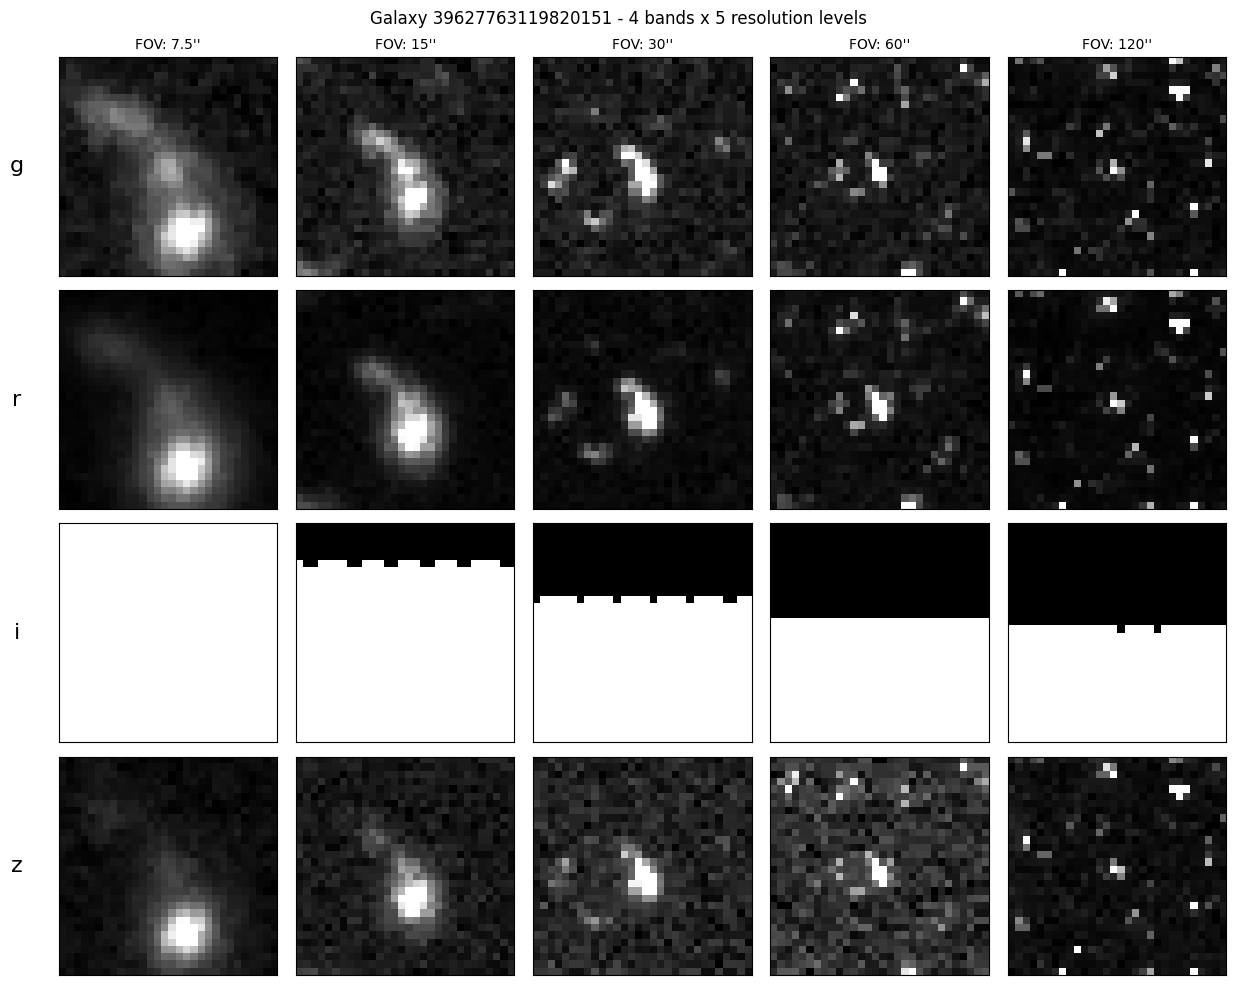

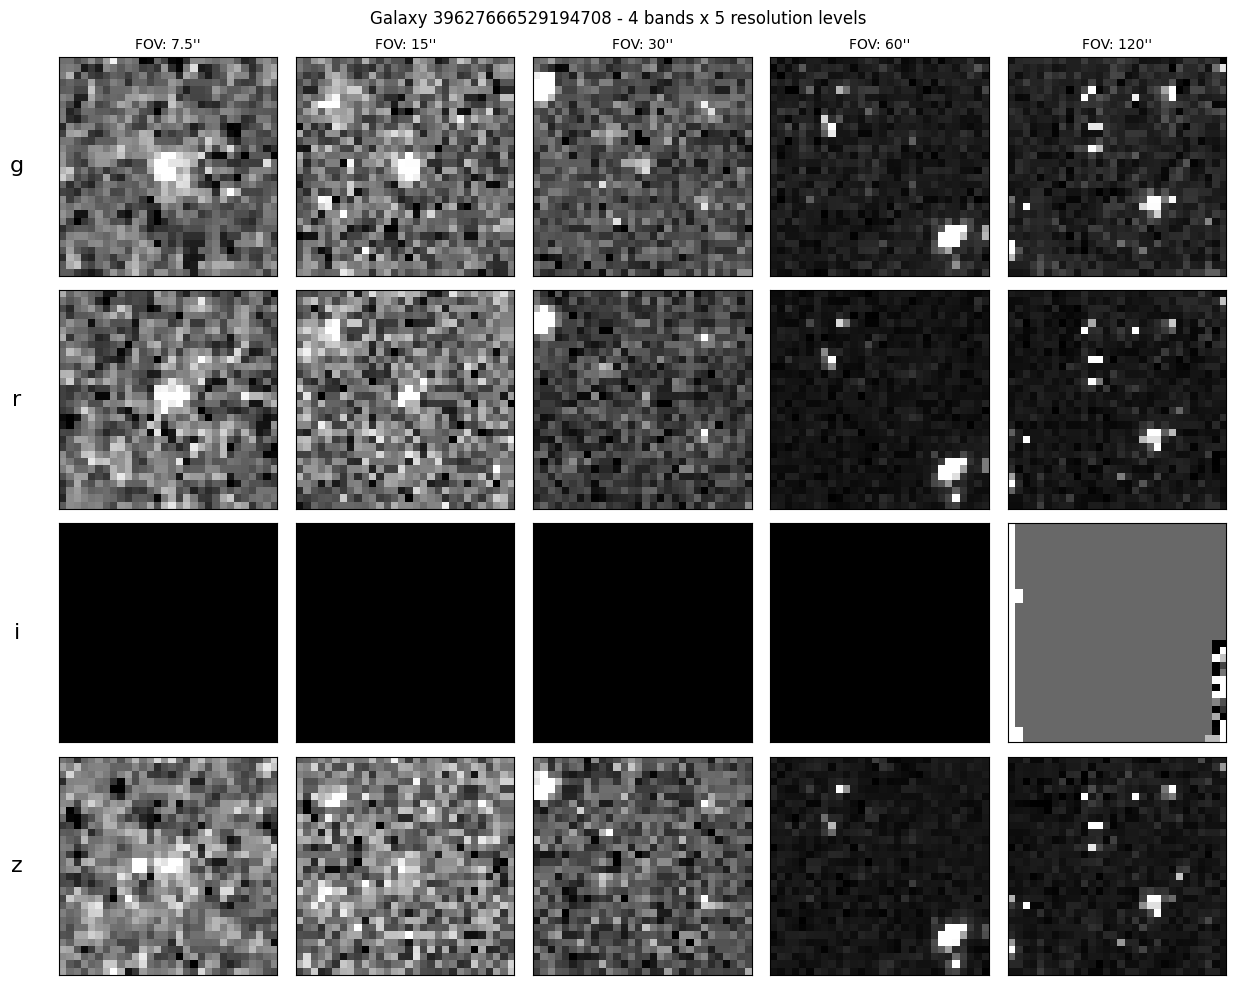

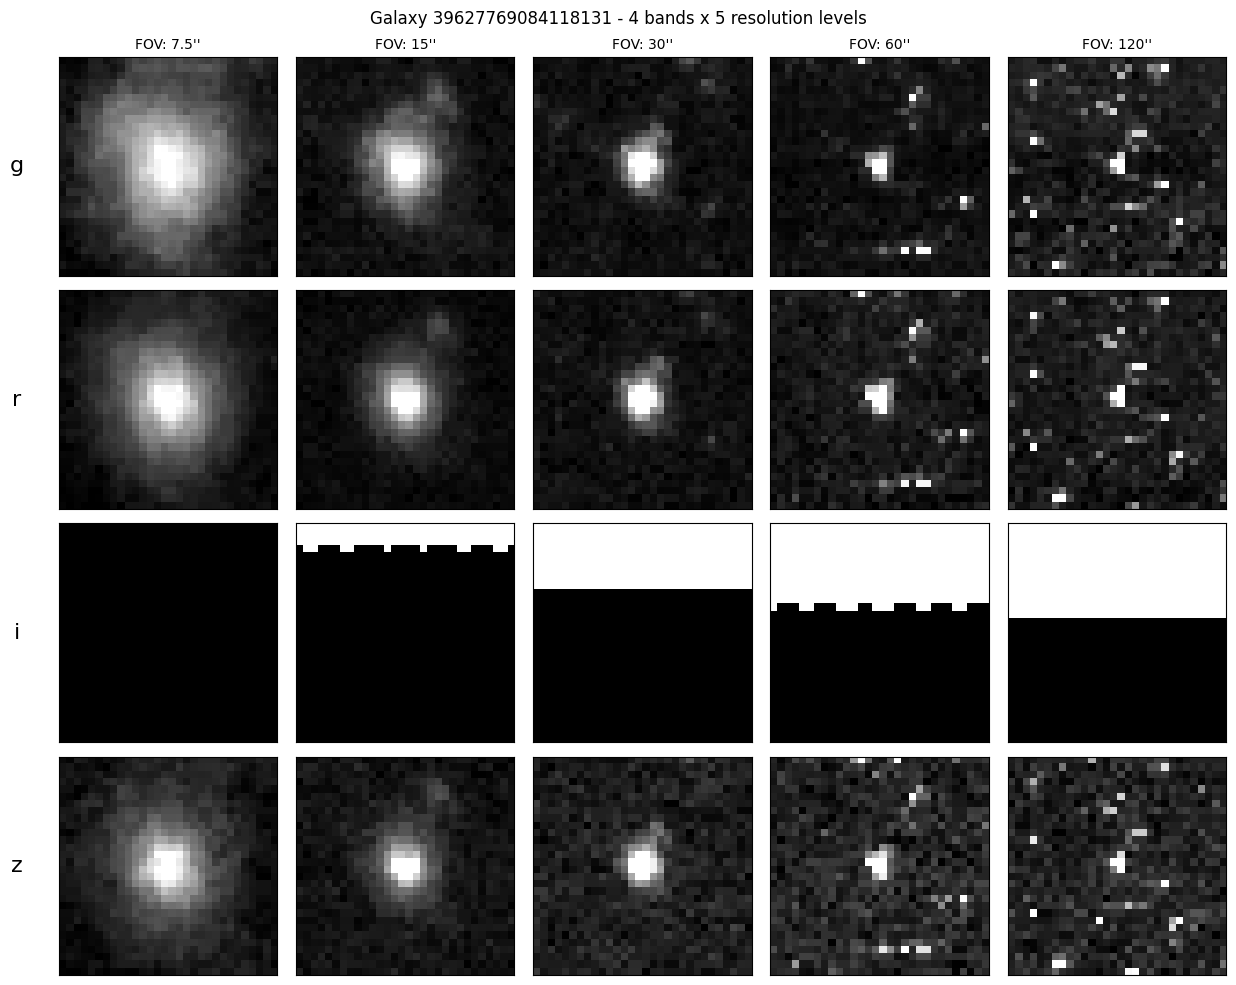

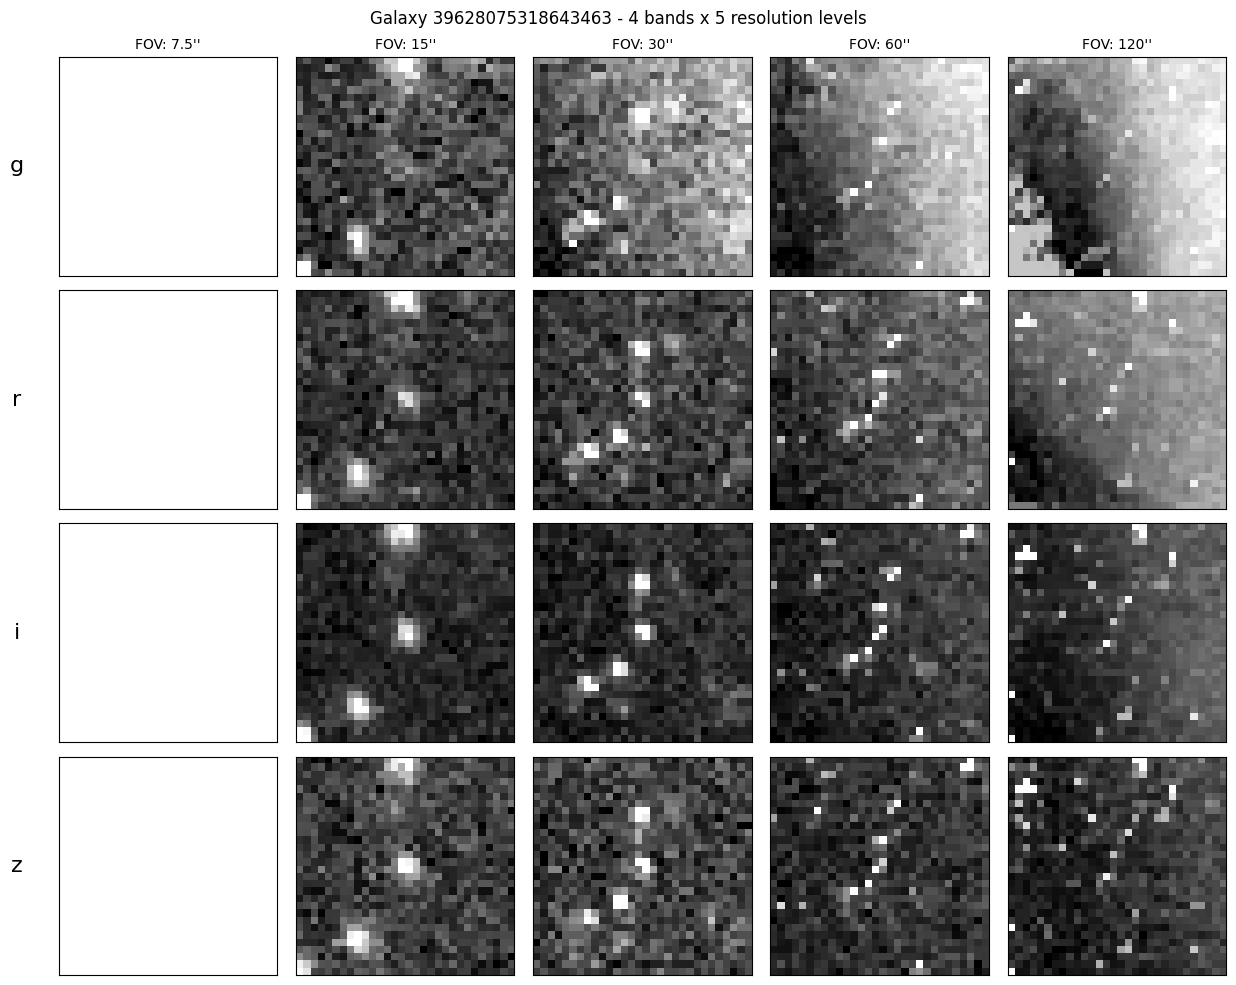

In [56]:
## para probar, tomamos los primeros 5 objetos

list_5 = idx_obj_prob[0:5]

for i in list_5:
    plot_galaxy(arrays[i], names[i])

In [40]:
""" 
La banda más problemática en los stamps es la banda i.
"""
print(f" Conteo de apariciones de bandas, que presentan valores nulos en los stamps \n {df_stamps_problematicos["band"].value_counts()}")

 Conteo de apariciones de bandas, que presentan valores nulos en los stamps 
 band
i    46
g     6
r     6
z     6
Name: count, dtype: int64


stamps que presenta problemas en alguna banda 
id_stamp
39628075318643463    4
39627992133010378    4
39628081215832087    4
39628057597707754    4
39628057589320324    4
39628039801274982    4
39627769163813429    1
39627763119820151    1
39627666529194708    1
39627769084118131    1
39627781167911625    1
39627666529194811    1
39627678579425371    1
39627768979264393    1
39627787312563282    1
39627684510175849    1
39627702767977210    1
39627630470763813    1
39627775224583838    1
39627775220383839    1
39627690705158347    1
39627696732377697    1
39627762931073163    1
39627829607926770    1
39627805452927144    1
39627823568130944    1
39627630458180165    1
39627775119725033    1
39627763044323293    1
39627666600496361    1
39627769084117095    1
39627817339584632    1
39627696736567418    1
39627654567039653    1
39627829607925045    1
39627684606644817    1
2842429522706435     1
39627762931073206    1
39627781255987974    1
39627690646437978    1
2714958722760707     1
3

/home/tamara/hips-env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


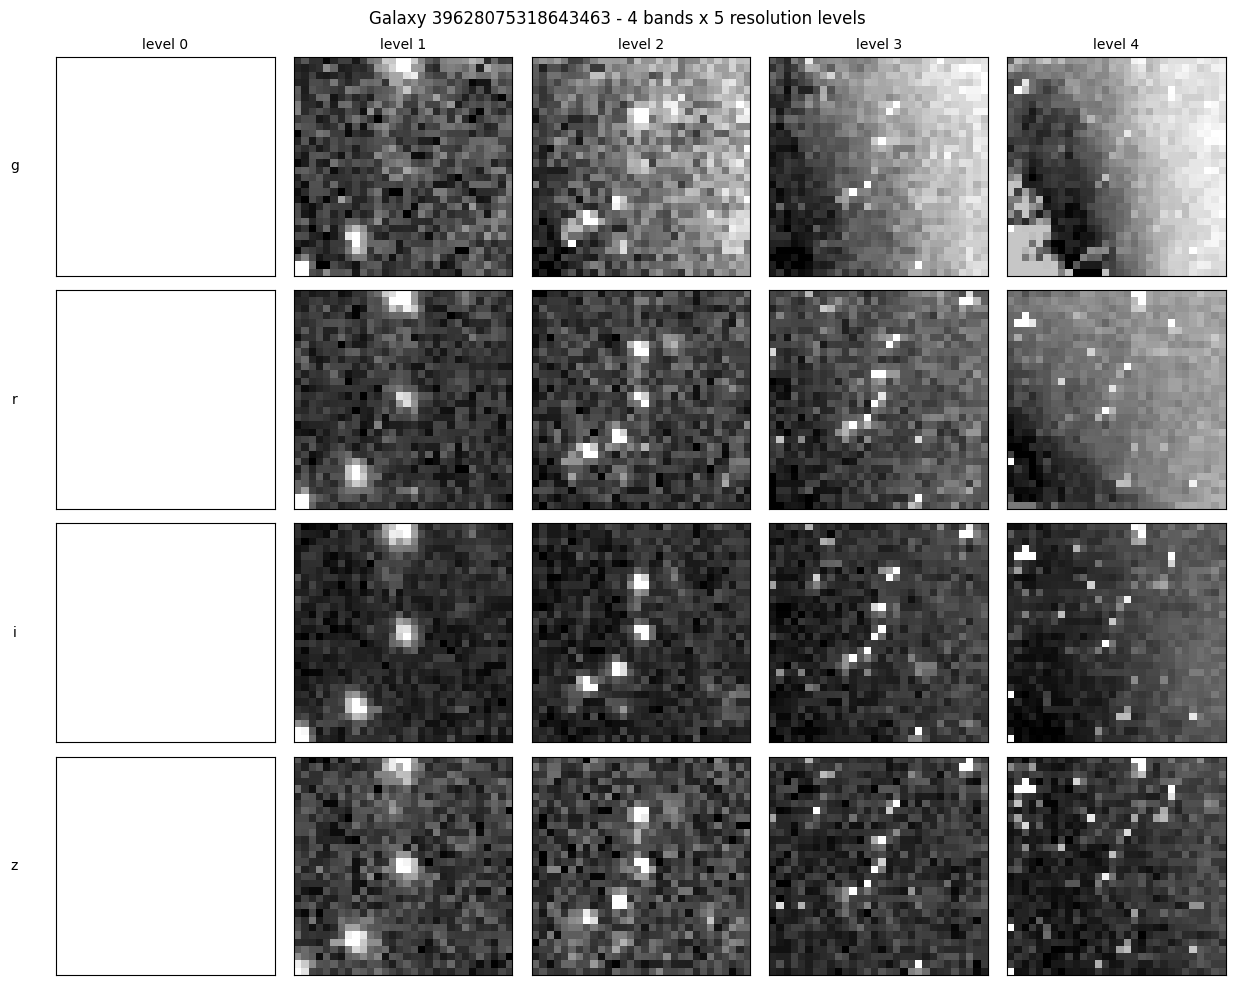

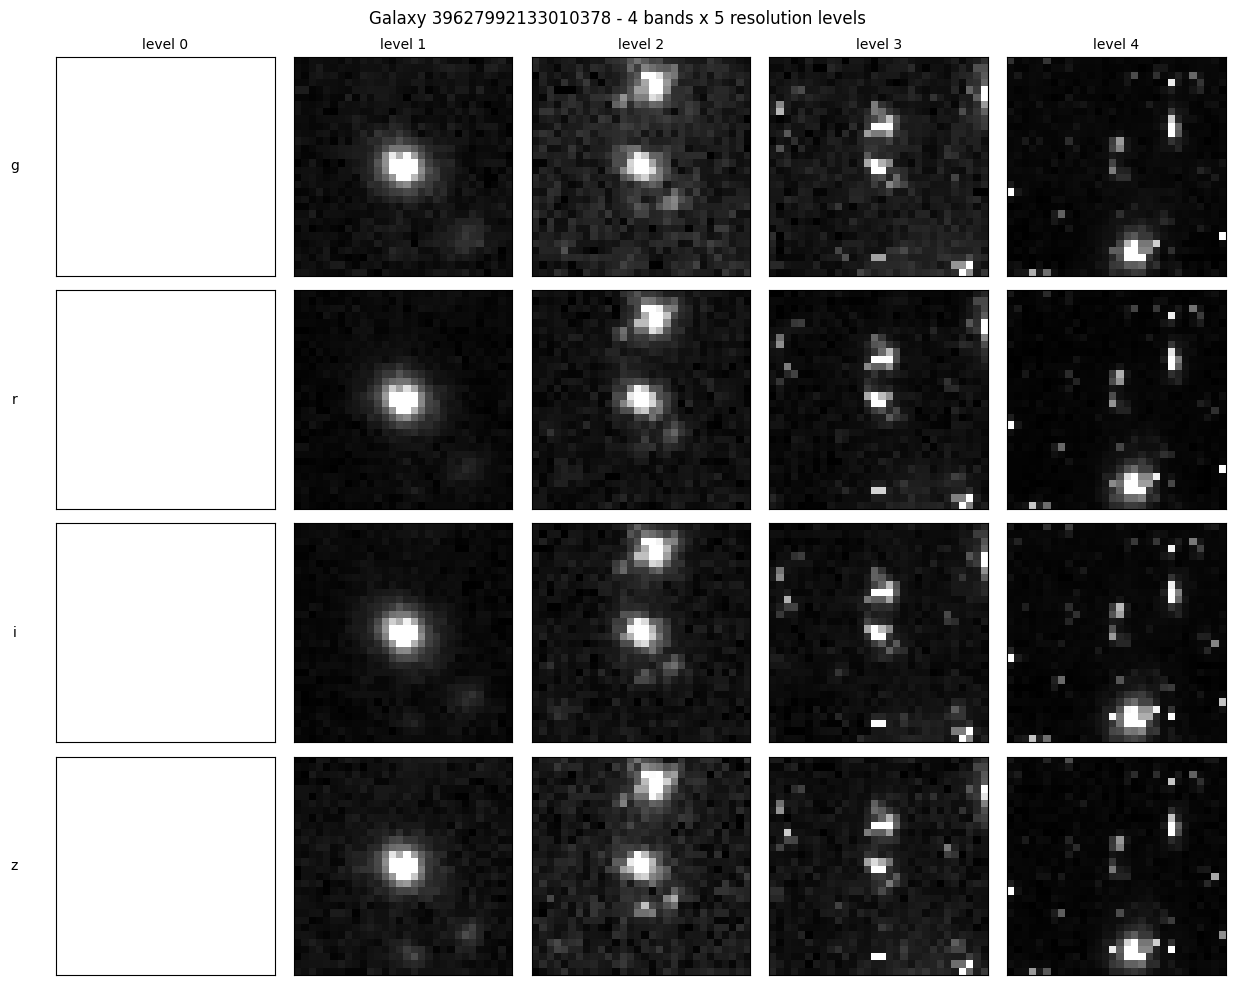

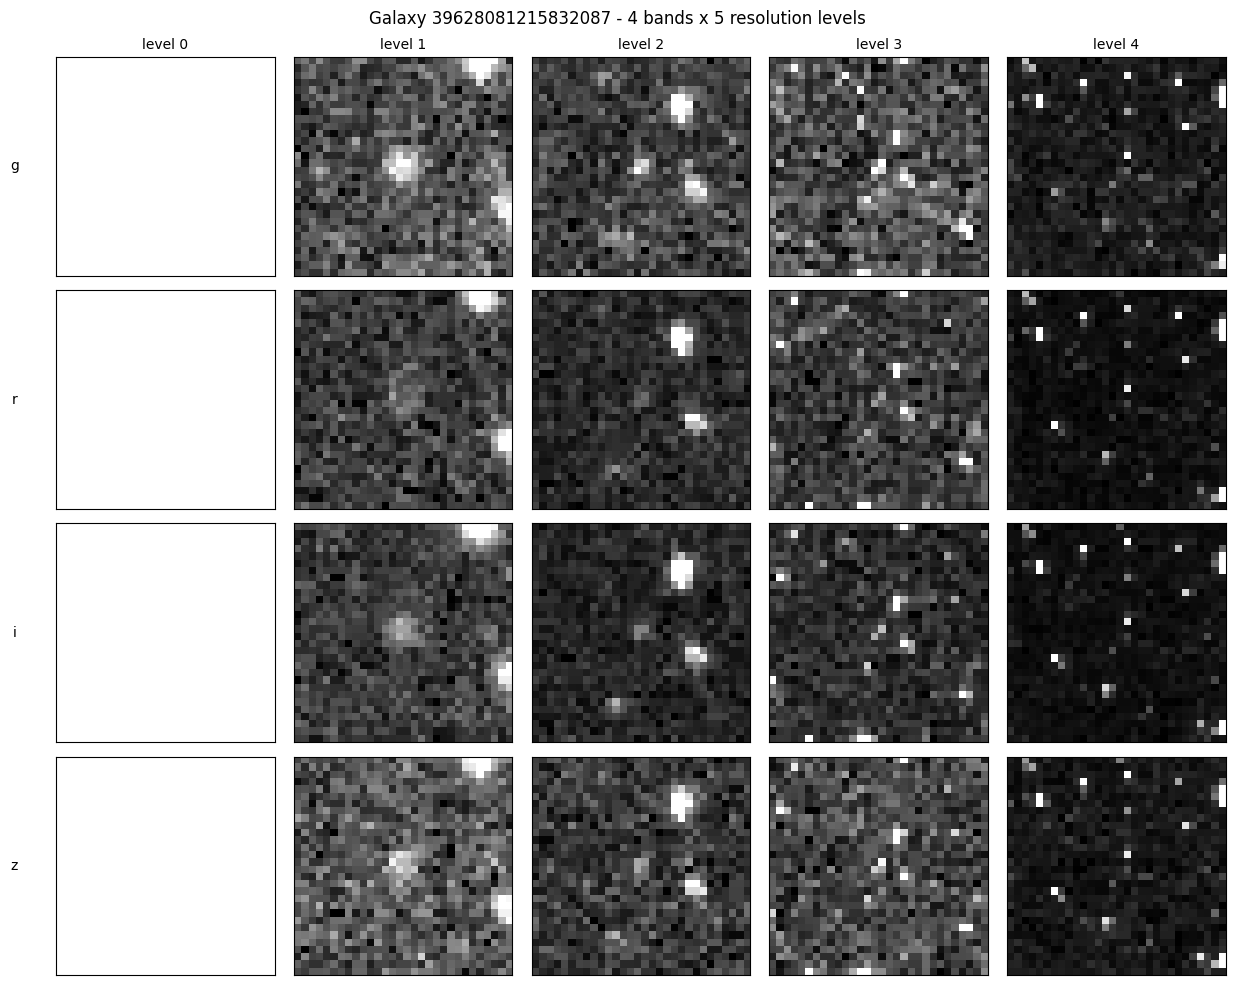

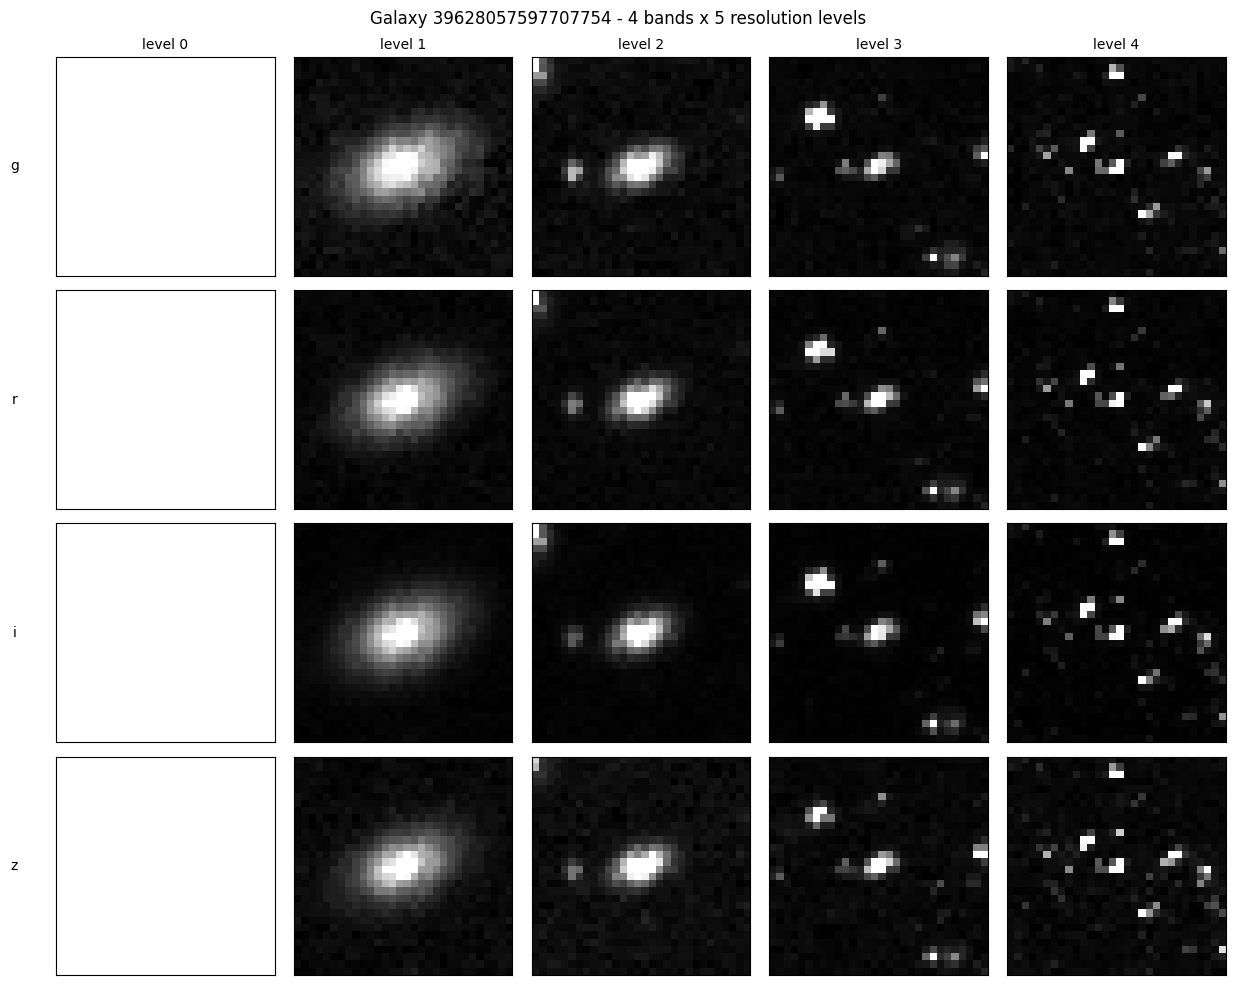

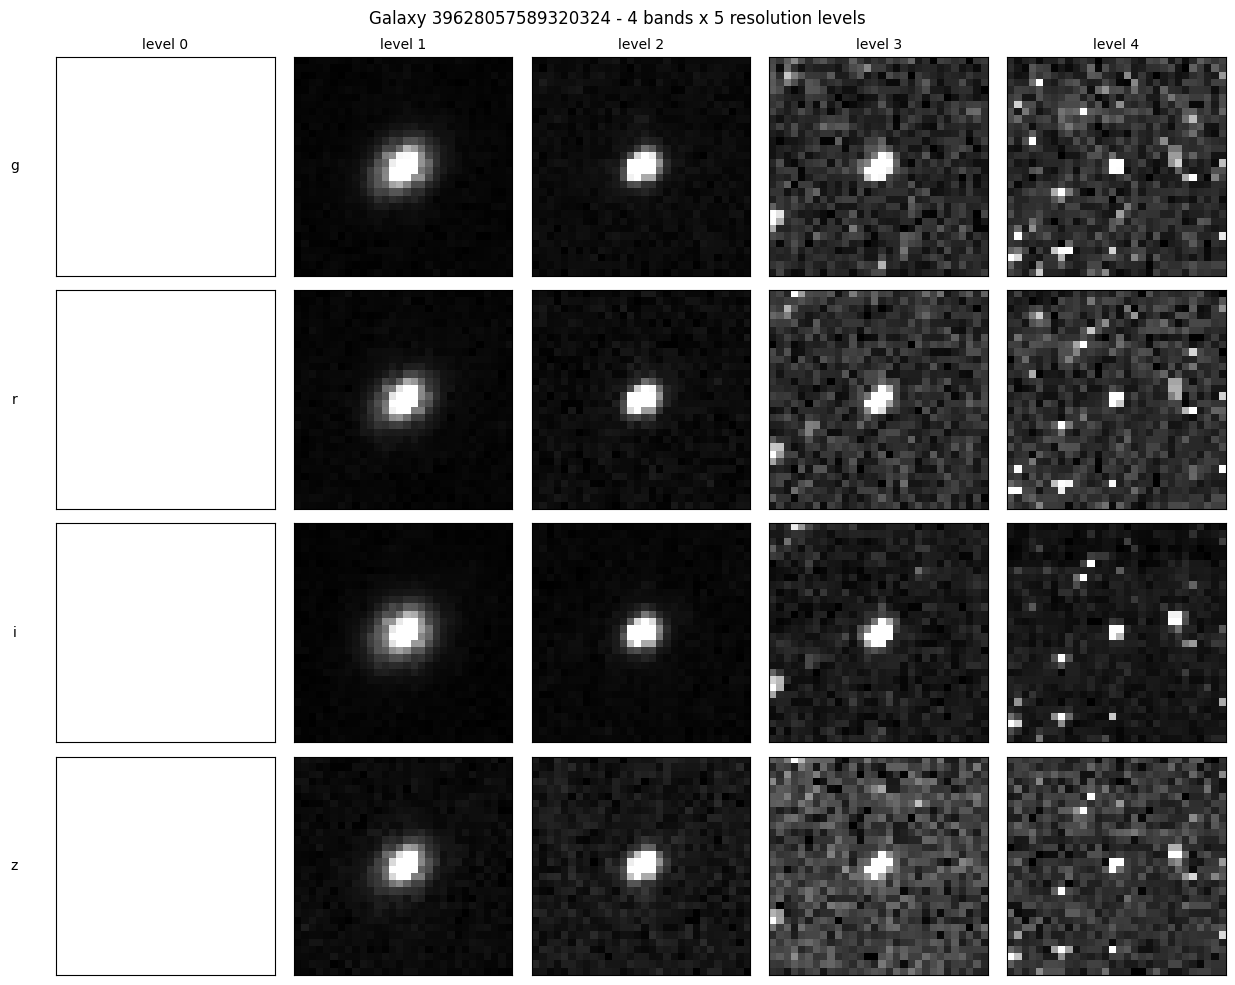

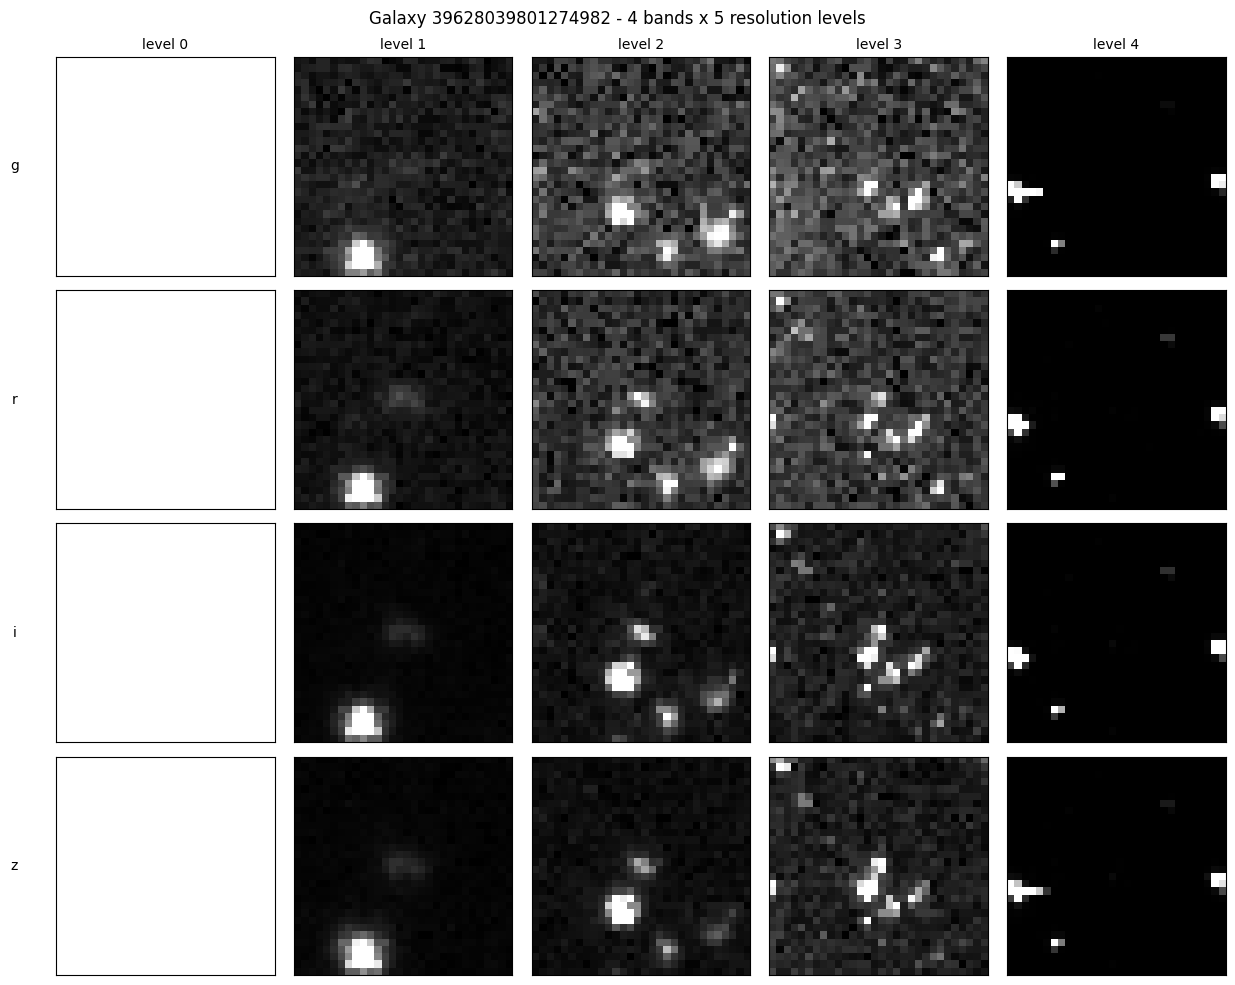

In [47]:
## Con values counts se pueden ver que stamps aparecen + de 1 vez
## 
print(f"stamps que presenta problemas en alguna banda \n{df_stamps_problematicos["id_stamp"].value_counts()}")
### Se identidican 5 stamps que presentan problemas en las 4 bandas.

conteos = df_stamps_problematicos["id_stamp"].value_counts()
ids_stamps_prob_repetidos = conteos[conteos > 1].index.tolist()

idx_obj_prob = []
for i in ids_stamps_prob_repetidos: # recorre los ids de los stamps
    w = names.index(i)
    idx_obj_prob.append(w)

for i in idx_obj_prob:
    plot_galaxy(arrays[i], names[i])

In [42]:
"""
El nivel de resolución problemático sería el nivel 1.
Eso no quiere decir que hayan problemas en los otros niveles.
Sin embargo, da la casualidad que sea el nivel 1 en donde
hayan problemas con los stamps en todas las bandas.

"""

'\nEl nivel de resolución problemático sería el nivel 1.\nEso no quiere decir que hayan problemas en los otros niveles.\nSin embargo, da la casualidad que sea el nivel 1 en donde\nhayan problemas con los stamps en todas las bandas.\n\n'

In [ ]:
df_stamps_problematicos # id_stamps

,id_stamp,band,nivel_1,nivel_2,nivel_3,nivel_4,nivel_5
3650,39627769163813429,i,0,0,0,155,300
4054,39627763119820151,i,900,738,593,510,478
5342,39627666529194708,i,0,0,0,0,34
6454,39627769084118131,i,0,100,270,343,390
7856,39628075318643463,g,900,0,0,0,0
...,...,...,...,...,...,...,...
112634,39627624460320813,i,0,0,0,11,214
113774,39627684514365602,i,780,600,516,480,450
124046,39627654491543166,i,0,0,0,30,240
128446,39627823572320346,i,0,0,0,0,162


In [ ]:
### acá se eliminarán los stamps problemáticos

In [48]:
########### Estadísticas de flujo por stamp, para una banda y nivel dados
rows_all = []
 
for i, stamp in enumerate(arrays):
    for j, band in enumerate(BAND_LABELS):
        for k in range(N_LEVELS):
            img = stamp[j, k]
            valid = img[~np.isnan(img)]
            n_valid = len(valid)
 
            rows_all.append({
                "id"         : names[i],
                "band"       : band,
                "level"      : k + 1,
                "min"        : valid.min()              if n_valid else np.nan,
                "max"        : valid.max()              if n_valid else np.nan,
                "mean"       : valid.mean()             if n_valid else np.nan,
                "median"     : np.median(valid)         if n_valid else np.nan,
                "std"        : valid.std()              if n_valid else np.nan,
                "perc_1"     : np.percentile(valid, 1)  if n_valid else np.nan,
                "perc_99"    : np.percentile(valid, 99) if n_valid else np.nan,
                "null_pixels": int(np.isnan(img).sum()),
            })
 
df_stats = pd.DataFrame(rows_all)
print(f"df_stats shape: {df_stats.shape}")
print(df_stats.head(10))

df_stats shape: (658420, 11)
                  id band  level       min       max      mean    median  \
0  39627902047750789    g      1 -0.004691  0.020696  0.003195  0.002190   
1  39627902047750789    g      2 -0.004050  0.018022  0.001140  0.000704   
2  39627902047750789    g      3 -0.002622  0.185278  0.002408  0.000482   
3  39627902047750789    g      4 -0.001125  0.113111  0.000808  0.000136   
4  39627902047750789    g      5 -0.000721  0.088019  0.000496  0.000045   
5  39627902047750789    r      1 -0.008744  0.141518  0.013934  0.006998   
6  39627902047750789    r      2 -0.011386  0.127950  0.004383  0.002132   
7  39627902047750789    r      3 -0.005174  0.653370  0.006571  0.001156   
8  39627902047750789    r      4 -0.003333  0.355146  0.002140  0.000401   
9  39627902047750789    r      5 -0.001784  0.275776  0.001365  0.000149   

        std    perc_1   perc_99  null_pixels  
0  0.003901 -0.002443  0.016464            0  
1  0.002527 -0.002264  0.012922         

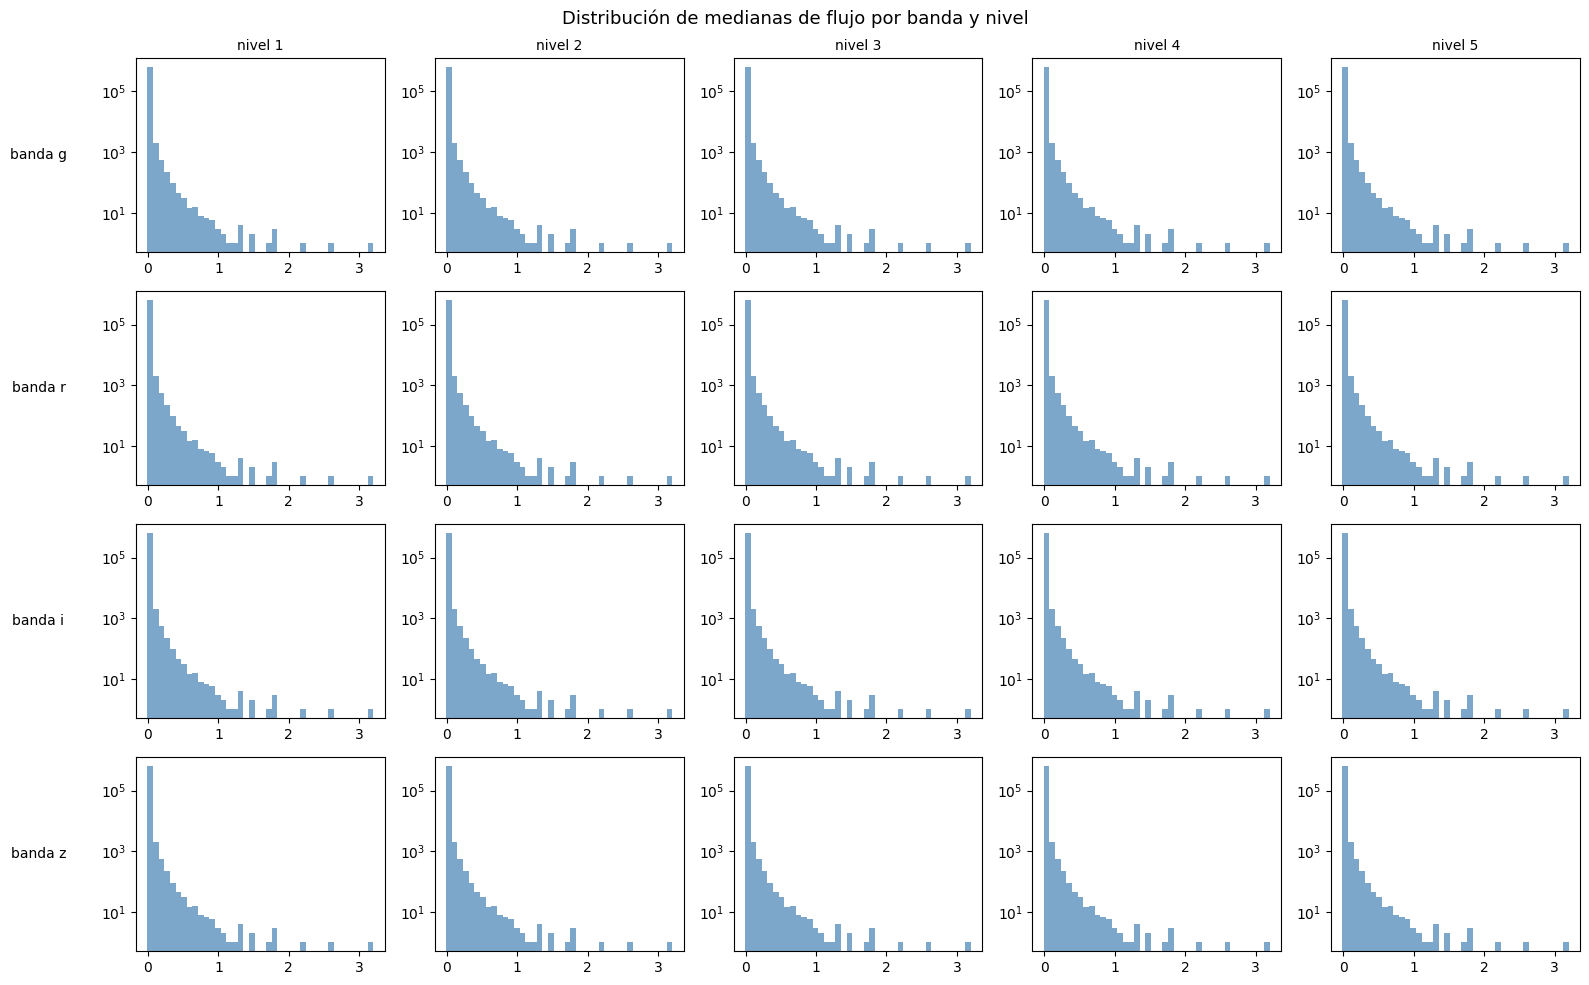

In [44]:
## AHORA SE ME OCURRE PLOTEAR ALGUNAS DISTRIBUCIONES
## un subplot de 4x5, donde de vean las distribuciones de la mediana por ejemplo.

fig, axes = plt.subplots(4, 5, figsize=(16, 10))
fig.suptitle("Distribución de medianas de flujo por banda y nivel", fontsize=13)

for row, band in enumerate(BAND_LABELS):
    for col, level in enumerate(range(1, 6)):
        ax = axes[row, col]

        medianas = df_stats["median"].dropna()

        ax.hist(medianas, bins=40, color="steelblue", alpha=0.7, edgecolor="none")
        ax.set_yscale("log")

        # etiquetas de fila solo en la primera columna
        if col == 0:
            ax.set_ylabel(f"banda {band}", fontsize=10, rotation=0,
                          labelpad=45, va="center")
        # etiquetas de columna solo en la primera fila
        if row == 0:
            ax.set_title(f"nivel {level}", fontsize=10)

plt.tight_layout()
plt.show()

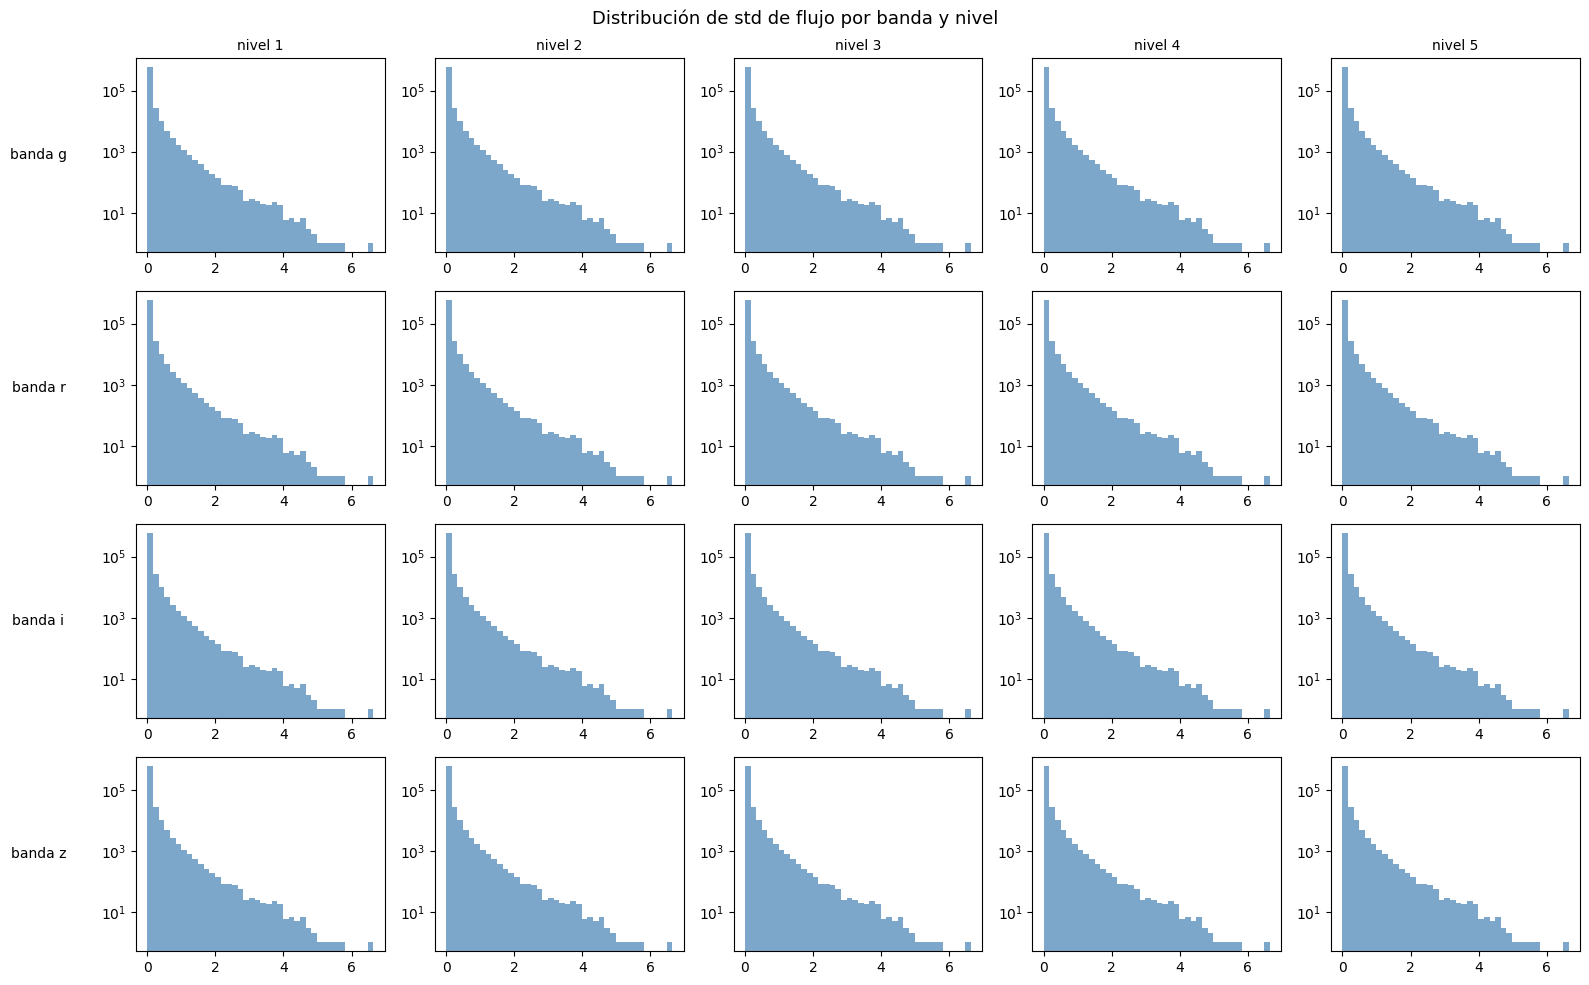

In [45]:
fig, axes = plt.subplots(4, 5, figsize=(16, 10))
fig.suptitle("Distribución de std de flujo por banda y nivel", fontsize=13)

for row, band in enumerate(BAND_LABELS):
    for col, level in enumerate(range(1, 6)):
        ax = axes[row, col]

        medianas = df_stats["std"].dropna()

        ax.hist(medianas, bins=40, color="steelblue", alpha=0.7, edgecolor="none")
        ax.set_yscale("log")

        # etiquetas de fila solo en la primera columna
        if col == 0:
            ax.set_ylabel(f"banda {band}", fontsize=10, rotation=0,
                          labelpad=45, va="center")
        # etiquetas de columna solo en la primera fila
        if row == 0:
            ax.set_title(f"nivel {level}", fontsize=10)

plt.tight_layout()
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9983/1721879070.py:44: SyntaxWarning: invalid escape sequence '\s'
  f"med={med:.3f}  \sigma={std:.3f}", fontsize=7)


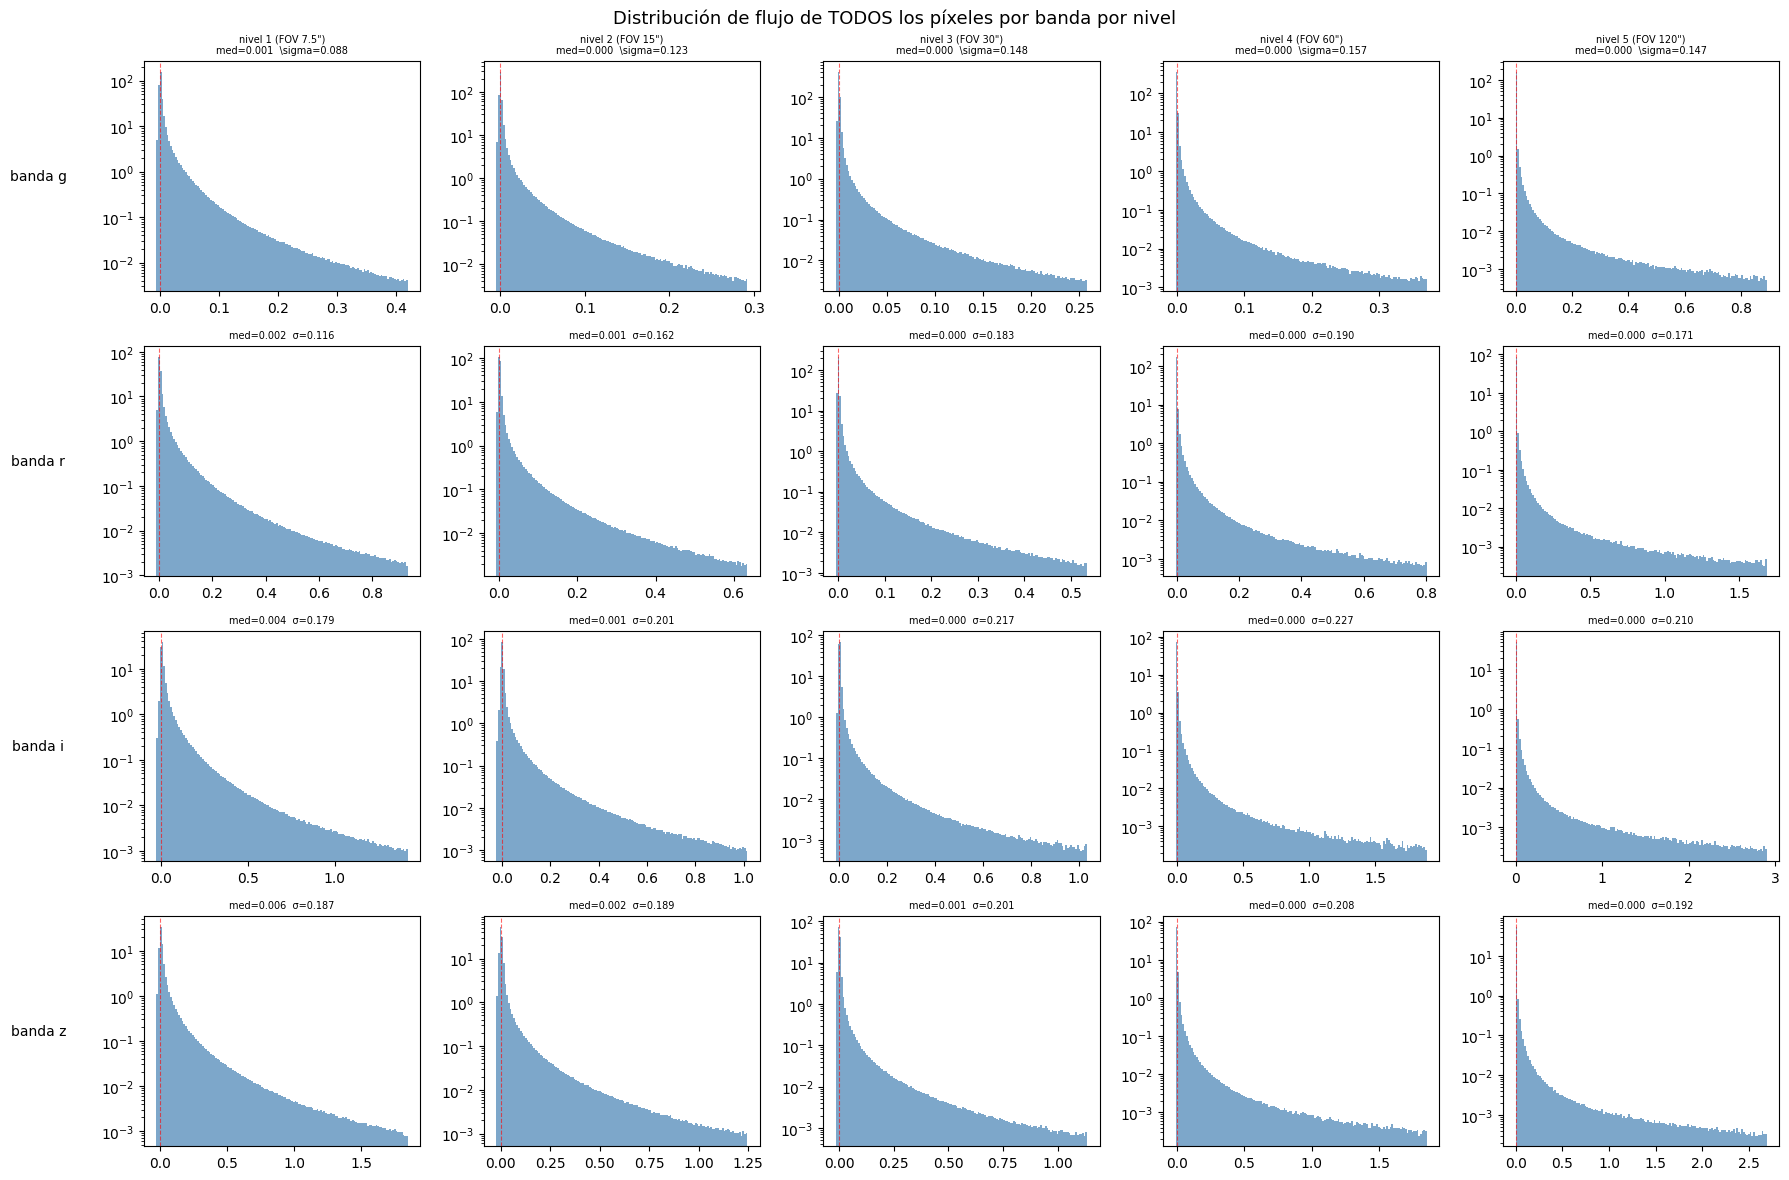

In [65]:
# %%
#  DISTRIBUCIÓN DE FLUJO A NIVEL DE PÍXEL
# Esto es distinto a graficar la mediana por stamp:
# acá se agregan TODOS los píxeles de todos los stamps
# para una combinación banda x nivel.
 
BAND_LABELS = ["g", "r", "i", "z"]
N_BANDS  = 4
N_LEVELS = 5
FOV_LABELS = ["7.5\"", "15\"", "30\"", "60\"", "120\""]

fig, axes = plt.subplots(N_BANDS, N_LEVELS, figsize=(18, 12))
fig.suptitle("Distribución de flujo de TODOS los píxeles por banda por nivel", fontsize=13)
 
for j, band in enumerate(BAND_LABELS):
    for k in range(N_LEVELS):
        ax = axes[j, k]
 
        # recolectar todos los píxeles 
        all_pixels = np.concatenate(
            [arrays[i][j, k].ravel() for i in range(len(arrays))]
        )
        all_pixels = all_pixels[~np.isnan(all_pixels)]
 
        # percentiles para definir rango del histograma
        p01, p999 = np.percentile(all_pixels, [0.1, 99.9])
        bins = np.linspace(p01, p999, 150)
 
        ax.hist(all_pixels, bins=bins, density=True,
                color="steelblue", alpha=0.7, edgecolor="none")
        ax.set_yscale("log")
        ax.axvline(0, color="red", ls="--", lw=0.8, alpha=0.6)
 
        # stats de referencia
        med = np.median(all_pixels)
        std = np.std(all_pixels)
        ax.set_title(f"med={med:.3f}  σ={std:.3f}", fontsize=7)
 
        if k == 0:
            ax.set_ylabel(f"banda {band}", fontsize=10,
                          rotation=0, labelpad=45, va="center")
        if j == 0:
            ax.set_title(f"nivel {k+1} (FOV {FOV_LABELS[k]})\n"
                         f"med={med:.3f}  \sigma={std:.3f}", fontsize=7)
 
plt.tight_layout()
plt.show()

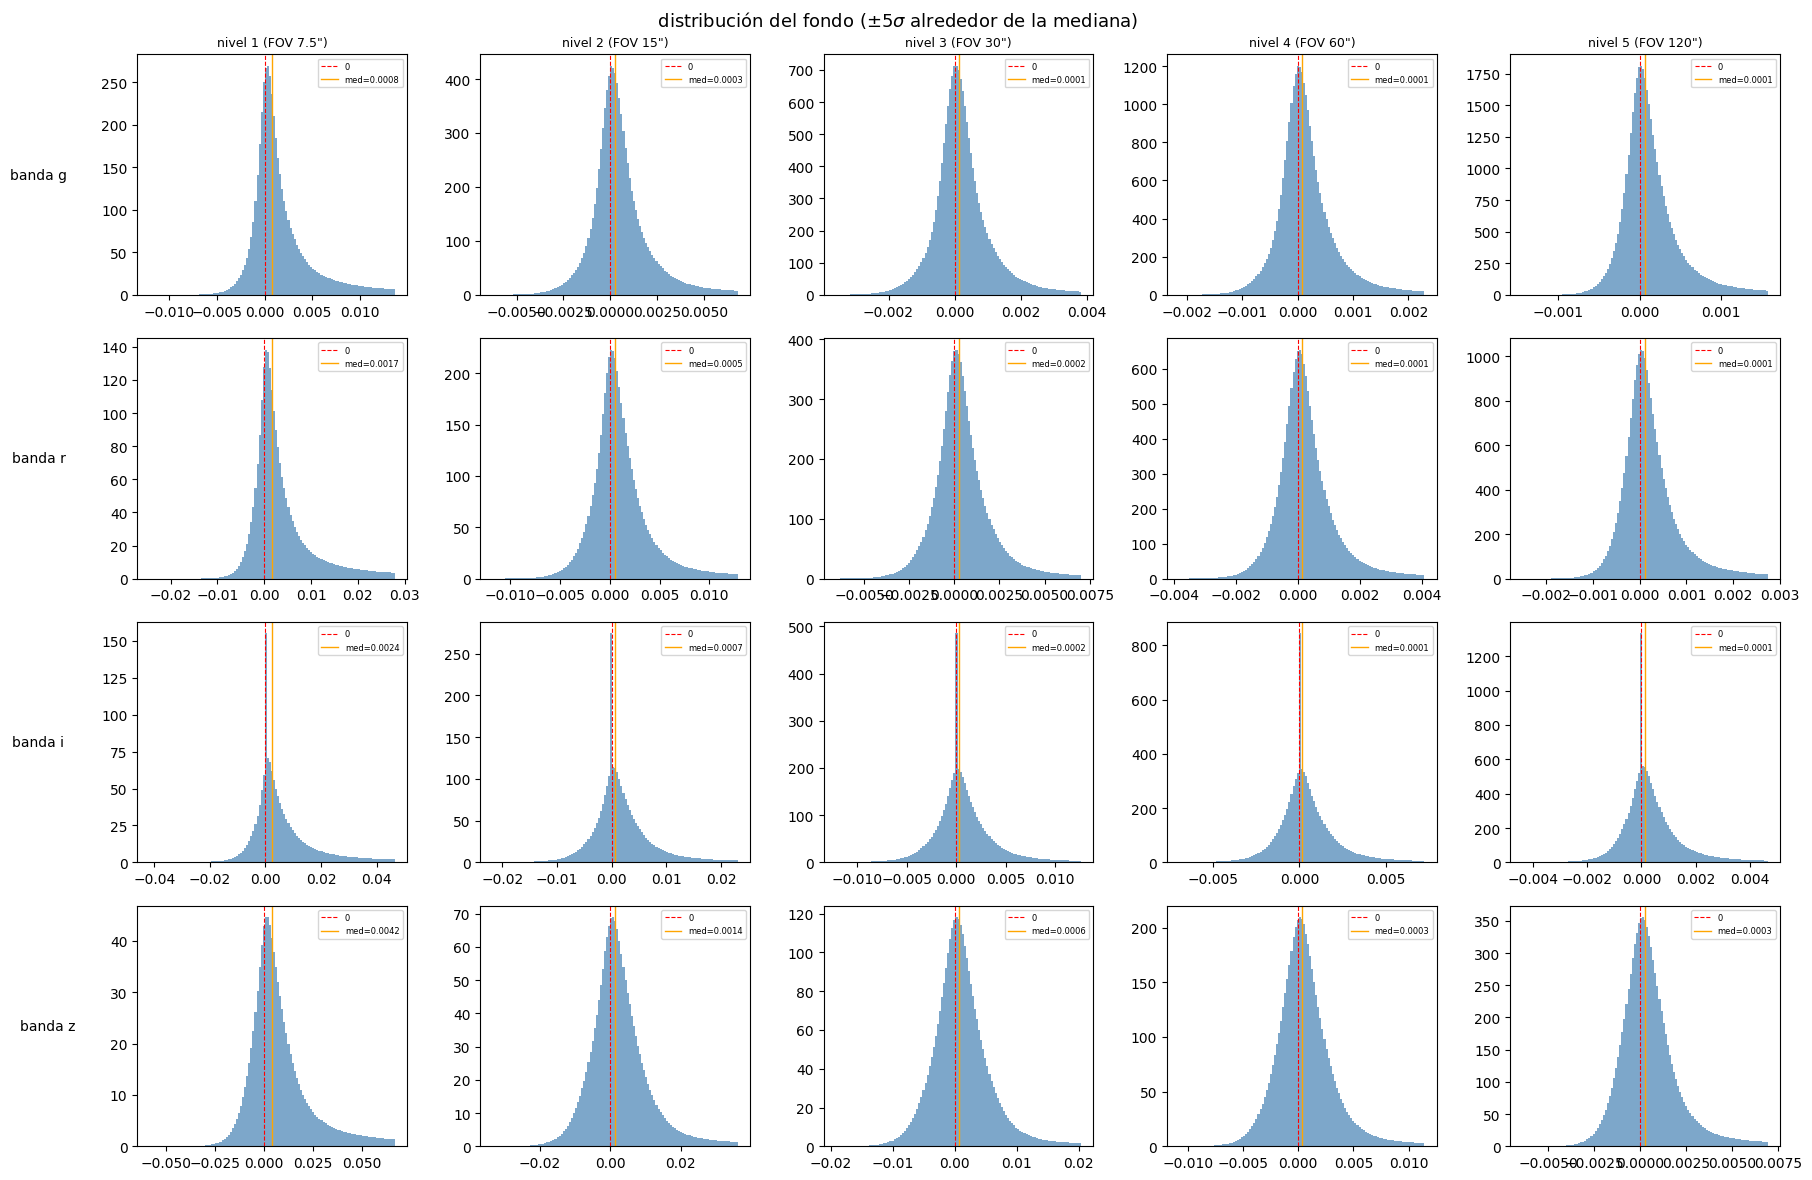

In [47]:
from astropy.stats import sigma_clipped_stats

## Ahora interesa estudiar el ruido del fondo.

# Se recorta el rango a +-5sigma  del fondo para ver 
# si el pico central es simétrico y centrado en 0.
# Si no está centrado en 0 hay problema de sustracción de cielo.
 
fig, axes = plt.subplots(N_BANDS, N_LEVELS, figsize=(18, 12))
fig.suptitle(r" distribución del fondo (±5$\sigma$ alrededor de la mediana)", fontsize=13)
 
for j, band in enumerate(BAND_LABELS):
    for k in range(N_LEVELS):
        ax = axes[j, k]
 
        all_pixels = np.concatenate(
            [arrays[i][j, k].ravel() for i in range(len(arrays))]
        )
        all_pixels = all_pixels[~np.isnan(all_pixels)]
 
        # sigma-clipping para estimar fondo              # Lo q hace sigma clipping es que calcula mediana y std de todos los pixeles, pero            
        bg_mean, bg_median, bg_std = sigma_clipped_stats(   # a partir de 3\sigma comienza a descartar valores (porque corresponden a fuentes)
            all_pixels, sigma=3, maxiters=5                     # entonces vuelve a calcular als stadisticas con los pixeles que en teoria corresponden solo a fondo
        )                                                           # se epseraria que en el nivel 1 la curva no esté tan centrada en 0, ya que es la imagen con el mayor zoom (se ve + galaxia)
 
        # rango: ±5\sigma alrededor de la mediana del fondo
        lo = bg_median - 5 * bg_std
        hi = bg_median + 5 * bg_std
        bins = np.linspace(lo, hi, 120)
 
        ax.hist(all_pixels, bins=bins, density=True,
                color="steelblue", alpha=0.7, edgecolor="none")
        
        ax.axvline(0, color="red", ls="--", lw=0.8, label="0")
        ax.axvline(bg_median, color="orange", ls="-", lw=1.0,
                   label=f"med={bg_median:.4f}")
 
        ax.legend(fontsize=6, loc="upper right")
 
        if k == 0:
            ax.set_ylabel(f"banda {band}", fontsize=10,
                          rotation=0, labelpad=45, va="center")
        if j == 0:
            ax.set_title(f"nivel {k+1} (FOV {FOV_LABELS[k]})", fontsize=9)
 
plt.tight_layout()
plt.show()

In [48]:

# VERIFICACIÓN DE SUSTRACCIÓN DE CIELO: usando píxeles de las esquinas
# Los píxeles en las esquinas del stamp deberían ser
# puro fondo (lejos del centro de la galaxia), por lo menos para la mayoría de los niveles.
# Si la media de las esquinas != 0, hay un offset residual.
#
# Definición de esquinas: parches de 5x5 (por ahora ) en cada esquina
# Eso quiere decir que del stamp 30x30 --- 100 píxeles de fondo por stamp.
 
CORNER_SIZE = 5
 
corner_mask = np.zeros((30, 30), dtype=bool)
corner_mask[:CORNER_SIZE, :CORNER_SIZE]   = True   # esquina sup-izq
corner_mask[:CORNER_SIZE, -CORNER_SIZE:]  = True   # esquina sup-der
corner_mask[-CORNER_SIZE:, :CORNER_SIZE]  = True   # esquina inf-izq
corner_mask[-CORNER_SIZE:, -CORNER_SIZE:] = True   # esquina inf-der
 
print(f"Píxeles de esquina por stamp: {corner_mask.sum()}")
 
# calcular media y std de las esquinas por stamp x banda x nivel

rows_bg = []
 
for i, stamp in enumerate(arrays):
    for j, band in enumerate(BAND_LABELS):
        for k in range(N_LEVELS):
            img = stamp[j, k]
            corners = img[corner_mask]
            valid = corners[~np.isnan(corners)]
            n_valid = len(valid)
 
            rows_bg.append({
                "id"         : names[i],
                "band"       : band,
                "level"      : k + 1,
                "bg_mean"    : valid.mean()        if n_valid else np.nan,
                "bg_median"  : np.median(valid)    if n_valid else np.nan,
                "bg_std"     : valid.std()         if n_valid else np.nan,
            })
 
df_bg = pd.DataFrame(rows_bg)
print(f"df_bg shape: {df_bg.shape}")
 

Píxeles de esquina por stamp: 100
df_bg shape: (658420, 6)


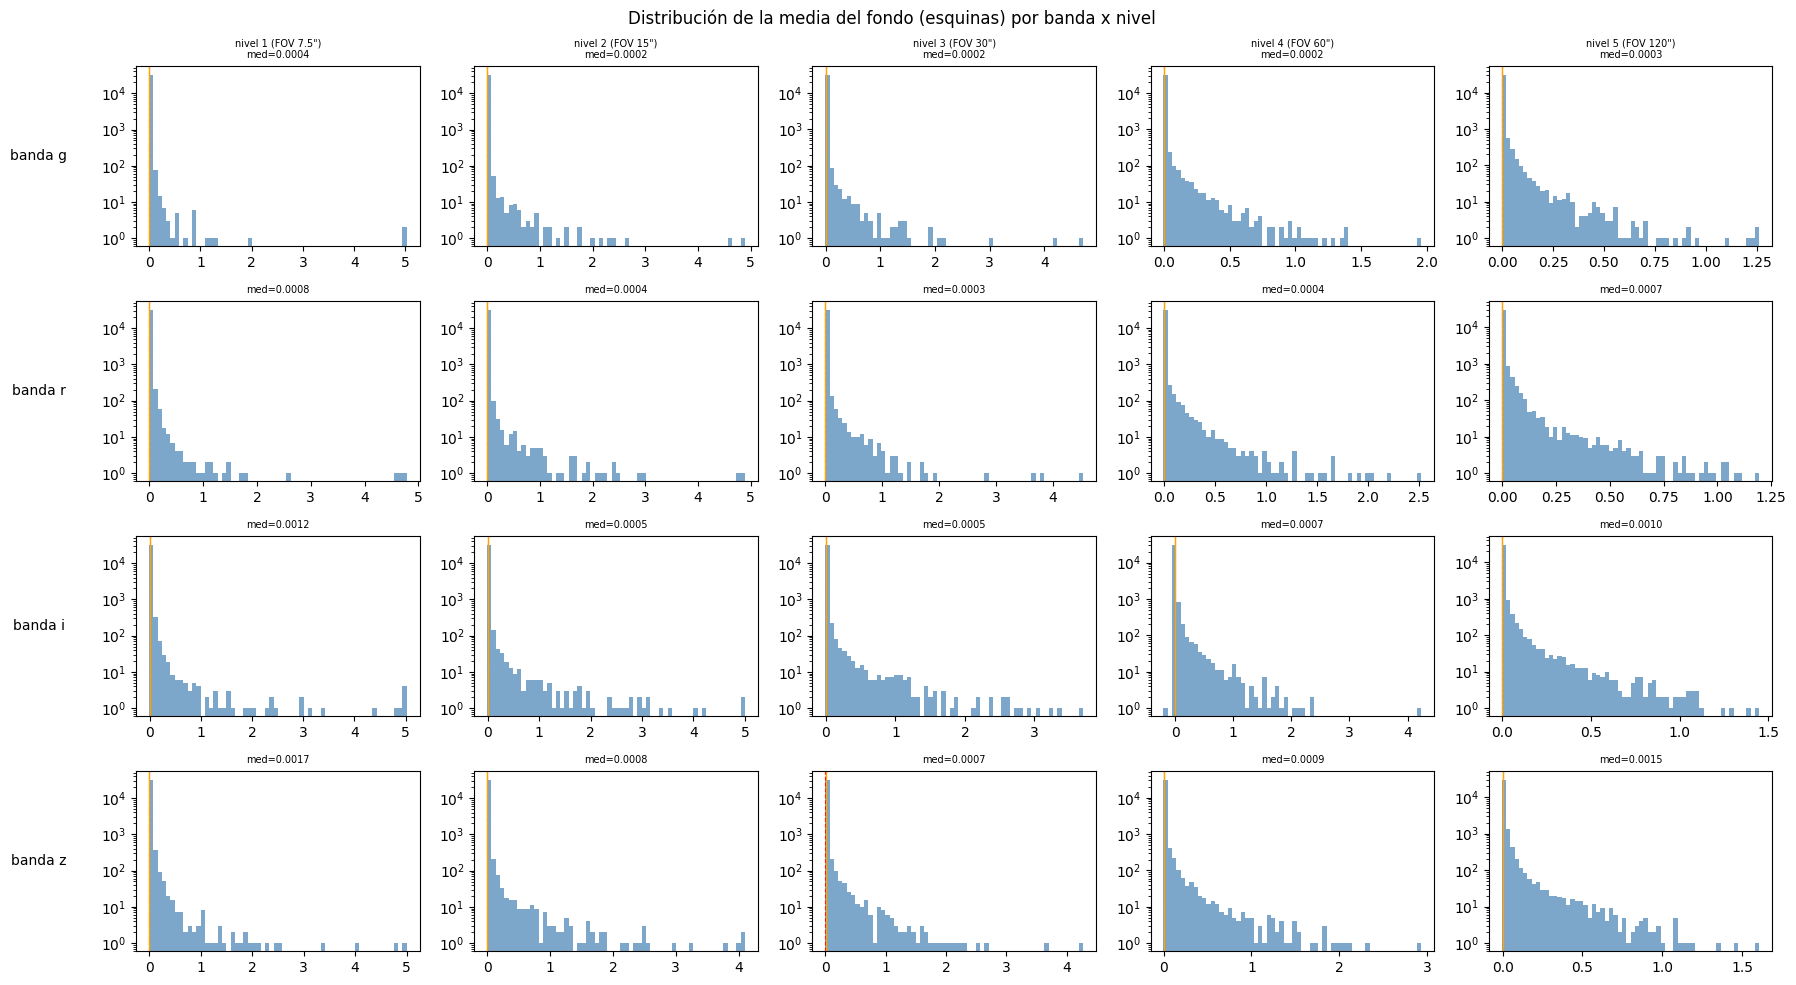

In [49]:
# Distribución de la media del fondo (esquinas) por banda x nivel
# Si la sustracción de cielo es correcta, las distribuciones
# deben estar centradas en 0.
 
fig, axes = plt.subplots(N_BANDS, N_LEVELS, figsize=(18, 10))
fig.suptitle("Distribución de la media del fondo (esquinas) por banda x nivel ",
             fontsize=12)
 
for j, band in enumerate(BAND_LABELS):
    for k in range(N_LEVELS):
        ax = axes[j, k]
        level = k + 1
        subset = df_bg[(df_bg["band"] == band) & (df_bg["level"] == level)]
        vals = subset["bg_mean"].dropna()
 
        ax.hist(vals, bins=60, color="steelblue", alpha=0.7, edgecolor="none")
        ax.axvline(0, color="red", ls="--", lw=0.8)
        ax.axvline(vals.median(), color="orange", ls="-", lw=1.0)
        ax.set_yscale("log")
 
        ax.set_title(f"med={vals.median():.4f}", fontsize=7)
 
        if k == 0:
            ax.set_ylabel(f"banda {band}", fontsize=10,
                          rotation=0, labelpad=45, va="center")
        if j == 0:
            ax.set_title(f"nivel {level} (FOV {FOV_LABELS[k]})\n"
                         f"med={vals.median():.4f}", fontsize=7)
 
plt.tight_layout()
plt.show()

**Comentario**: Es esperable que hayan outliers en los primeros niveles porque el stamp cubre casi todo el objeto. por lo que las esquinas bien son parte de la galaxia.

In [50]:
# Tabla resumen: offset medio del fondo por banda x nivel
pivot_bg = df_bg.groupby(["band", "level"])["bg_mean"].agg(
    ["median", "mean", "std"]
).round(5)
print("Resumen del fondo (esquinas) por banda x nivel:")
print(pivot_bg)

Resumen del fondo (esquinas) por banda x nivel:
             median     mean      std
band level                           
g    1      0.00036  0.00287  0.04560
     2      0.00020  0.00299  0.05714
     3      0.00018  0.00363  0.05862
     4      0.00022  0.00460  0.04196
     5      0.00031  0.00542  0.03619
i    1      0.00115  0.00852  0.09396
     2      0.00054  0.00761  0.09811
     3      0.00049  0.00831  0.08719
     4      0.00065  0.01028  0.07944
     5      0.00104  0.01080  0.05665
r    1      0.00076  0.00544  0.05728
     2      0.00037  0.00491  0.06991
     3      0.00034  0.00516  0.06216
     4      0.00044  0.00714  0.05818
     5      0.00069  0.00767  0.04253
z    1      0.00170  0.00925  0.07303
     2      0.00083  0.00775  0.08353
     3      0.00073  0.00817  0.07482
     4      0.00094  0.01042  0.07248
     5      0.00148  0.01104  0.05433


In [51]:
# ESTIMACIÓN DE RUIDO CON SIGMA-CLIPPING
# Para cada stamp se estima \sigma_bg usando sigma-clipping
# sobre todos los píxeles (no solo esquinas).
# Esto es más robusto porque el clipping elimina iterativamente los píxeles de galaxia.
 
rows_sc = []
 
for i, stamp in enumerate(arrays):
    for j, band in enumerate(BAND_LABELS):
        for k in range(N_LEVELS):
            img = stamp[j, k]
            valid = img[~np.isnan(img)]
 
            if len(valid) == 0:
                rows_sc.append({
                    "id": names[i], "band": band, "level": k + 1,
                    "sc_mean": np.nan, "sc_median": np.nan, "sc_std": np.nan,
                })
                continue
 
            sc_mean, sc_median, sc_std = sigma_clipped_stats(
                valid, sigma=3, maxiters=5
            )
            rows_sc.append({
                "id"        : names[i],
                "band"      : band,
                "level"     : k + 1,
                "sc_mean"   : sc_mean,
                "sc_median" : sc_median,
                "sc_std"    : sc_std,
            })
 
df_sc = pd.DataFrame(rows_sc)
print(f"df_sc shape: {df_sc.shape}")

df_sc shape: (658420, 6)


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_19440/3216003026.py:6: SyntaxWarning: invalid escape sequence '\s'
  fig.suptitle("Distribución de $\sigma_{bg}$ (sigma-clipped) por banda x nivel", fontsize=13)
/tmp/ipykernel_19440/3216003026.py:20: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"med \sigma={med_val:.4f}", fontsize=7)
/tmp/ipykernel_19440/3216003026.py:27: SyntaxWarning: invalid escape sequence '\s'
  f"med \sigma={med_val:.4f}", fontsize=7)


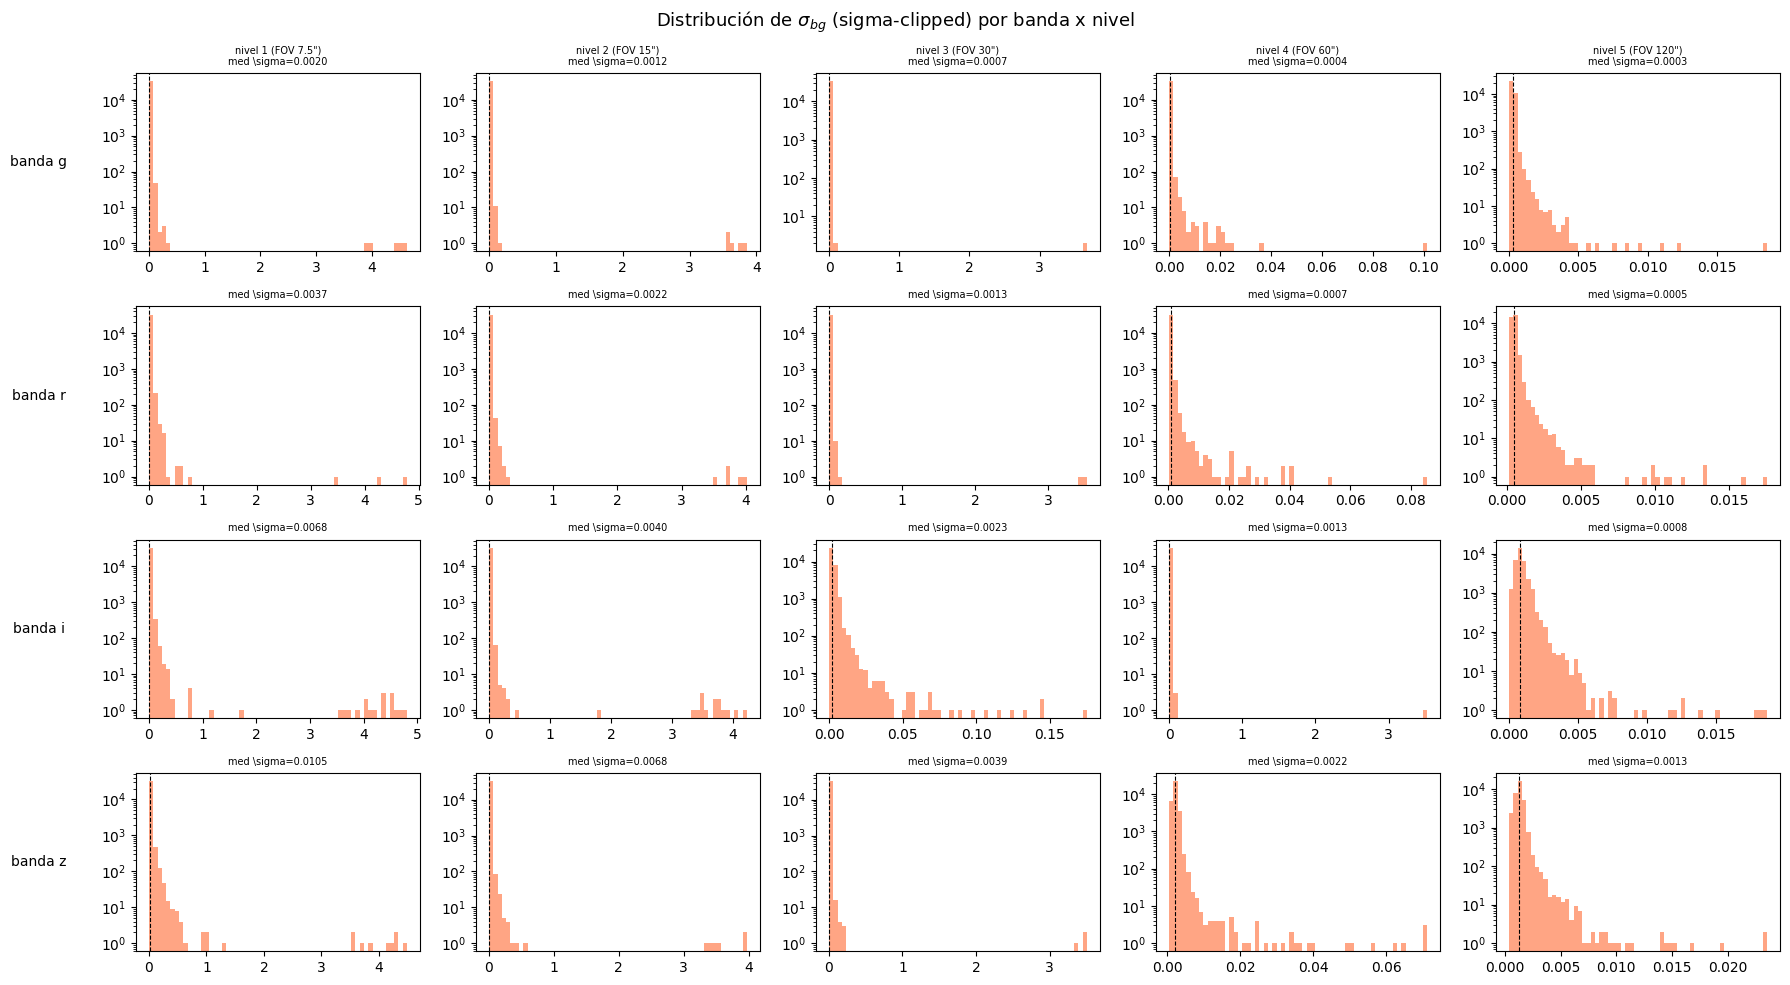

In [52]:
# Distribución de \sigma_bg (sigma-clipped) por banda x nivel
# Esto muestra cuánto ruido hay en cada combinación.
# Bandas más ruidosas ---- \sigma_bg más alto.
 
fig, axes = plt.subplots(N_BANDS, N_LEVELS, figsize=(18, 10))
fig.suptitle("Distribución de $\sigma_{bg}$ (sigma-clipped) por banda x nivel", fontsize=13)
 
for j, band in enumerate(BAND_LABELS):
    for k in range(N_LEVELS):
        ax = axes[j, k]
        level = k + 1
        subset = df_sc[(df_sc["band"] == band) & (df_sc["level"] == level)]
        vals = subset["sc_std"].dropna()
 
        ax.hist(vals, bins=60, color="coral", alpha=0.7, edgecolor="none")
        ax.set_yscale("log")
 
        med_val = vals.median()
        ax.axvline(med_val, color="k", ls="--", lw=0.8)
        ax.set_title(f"med \sigma={med_val:.4f}", fontsize=7)
 
        if k == 0:
            ax.set_ylabel(f"banda {band}", fontsize=10,
                          rotation=0, labelpad=45, va="center")
        if j == 0:
            ax.set_title(f"nivel {level} (FOV {FOV_LABELS[k]})\n"
                         f"med \sigma={med_val:.4f}", fontsize=7)
 
plt.tight_layout()
plt.show()

In [53]:
# Resumen de \sigma_bg por banda x nivel
pivot_sc = df_sc.groupby(["band", "level"])["sc_std"].agg(
    ["median", "mean", "std"]
).round(5)
print("Resumen de \sigma_bg (sigma-clipped) por banda x nivel:")
print(pivot_sc)

Resumen de \sigma_bg (sigma-clipped) por banda x nivel:
             median     mean      std
band level                           
g    1      0.00198  0.00446  0.05368
     2      0.00122  0.00219  0.04537
     3      0.00070  0.00102  0.02844
     4      0.00041  0.00044  0.00074
     5      0.00027  0.00029  0.00023
i    1      0.00678  0.01399  0.09935
     2      0.00403  0.00688  0.07744
     3      0.00228  0.00265  0.00322
     4      0.00129  0.00154  0.01947
     5      0.00081  0.00087  0.00053
r    1      0.00373  0.00812  0.04327
     2      0.00223  0.00369  0.04701
     3      0.00127  0.00169  0.02720
     4      0.00073  0.00080  0.00094
     5      0.00048  0.00051  0.00032
z    1      0.01048  0.01742  0.07187
     2      0.00682  0.00858  0.04981
     3      0.00395  0.00444  0.03301
     4      0.00221  0.00223  0.00137
     5      0.00129  0.00132  0.00052


<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_19440/2567666991.py:5: SyntaxWarning: invalid escape sequence '\s'
  print("Resumen de \sigma_bg (sigma-clipped) por banda x nivel:")


<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_19440/3812006052.py:18: SyntaxWarning: invalid escape sequence '\s'
  fig.suptitle("Distribución de SNR (píxel pico / \sigma_bg) por banda × nivel", fontsize=13)


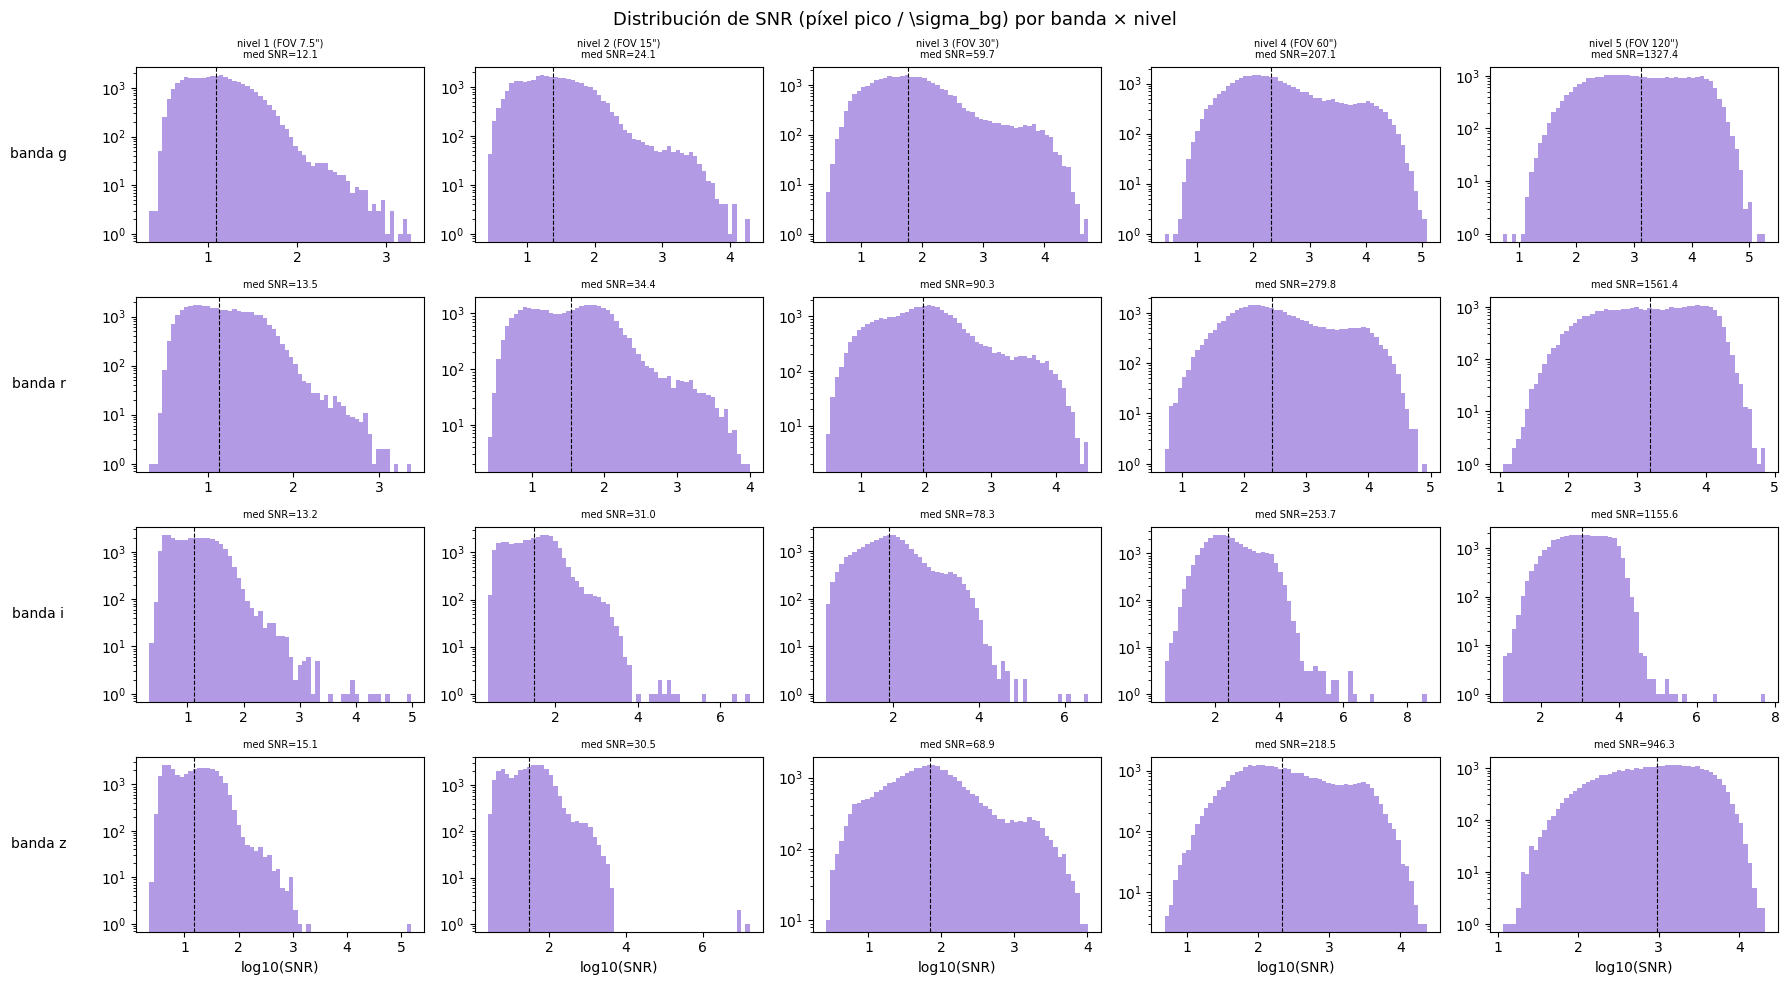

In [ ]:
# SNR POR STAMP
# SNR = flujo del píxel peak / \sigma_bg
# 
# Se usa el máximo del stamp 
# dividido por el \sigma estimado con sigma-clipping.
# Stamps con SNR bajo .. la galaxia apenas se distingue del ruido.
#  ni idea si esto estará bn

df_snr = df_stats.merge(
    df_sc[["id", "band", "level", "sc_std"]],
    on=["id", "band", "level"],
    how="left"
)
df_snr["snr_peak"] = df_snr["max"] / df_snr["sc_std"]
 
# histograma de SNR por banda x nivel
fig, axes = plt.subplots(N_BANDS, N_LEVELS, figsize=(18, 10))
fig.suptitle("Distribución de SNR (píxel peak / \sigma_bg) por banda × nivel", fontsize=13)
 
for j, band in enumerate(BAND_LABELS):
    for k in range(N_LEVELS):
        ax = axes[j, k]
        level = k + 1
        subset = df_snr[(df_snr["band"] == band) & (df_snr["level"] == level)]
        vals = subset["snr_peak"].dropna()
        vals = vals[np.isfinite(vals)]
 
        # usar escala log en x por el rango dinámico amplio
        vals_log = np.log10(vals[vals > 0])
 
        ax.hist(vals_log, bins=60, color="mediumpurple",
                alpha=0.7, edgecolor="none")
        ax.set_yscale("log")
 
        med_snr = np.median(vals[vals > 0])
        ax.axvline(np.log10(med_snr), color="k", ls="--", lw=0.8)
        ax.set_title(f"med SNR={med_snr:.1f}", fontsize=7)
 
        if k == 0:
            ax.set_ylabel(f"banda {band}", fontsize=10,
                          rotation=0, labelpad=45, va="center")
        if j == 0:
            ax.set_title(f"nivel {level} (FOV {FOV_LABELS[k]})\n"
                         f"med SNR={med_snr:.1f}", fontsize=7)
        if j == N_BANDS - 1:
            ax.set_xlabel("log10(SNR)")
 
plt.tight_layout()
plt.show()

In [55]:
# Stamps con SNR bajo: ¿cuántos tienen SNR < 3 por banda?
# (SNR < 3 significa que el píxel más brillante apenas supera
# 3 veces el ruido, o sea la galaxia es muy débil)
 
print("Fracción de stamps con SNR_peak < 3 por banda × nivel:")
for j, band in enumerate(BAND_LABELS):
    fracs = []
    for k in range(N_LEVELS):
        level = k + 1
        subset = df_snr[(df_snr["band"] == band) & (df_snr["level"] == level)]
        vals = subset["snr_peak"].dropna()
        frac = (vals < 3).mean()
        fracs.append(f"L{level}: {frac:.3f}")
    print(f"  {band}: {', '.join(fracs)}")

Fracción de stamps con SNR_peak < 3 por banda × nivel:
  g: L1: 0.001, L2: 0.001, L3: 0.000, L4: 0.000, L5: 0.000
  r: L1: 0.001, L2: 0.000, L3: 0.000, L4: 0.000, L5: 0.000
  i: L1: 0.004, L2: 0.004, L3: 0.001, L4: 0.000, L5: 0.000
  z: L1: 0.002, L2: 0.002, L3: 0.000, L4: 0.000, L5: 0.000


Stamps con tipo asignado: 555140 de 658420


/tmp/ipykernel_19440/3203203402.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="morph_type", y="log_snr",
/tmp/ipykernel_19440/3203203402.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="morph_type", y="log_snr",
/tmp/ipykernel_19440/3203203402.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="morph_type", y="log_snr",
/tmp/ipykernel_19440/3203203402.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variabl

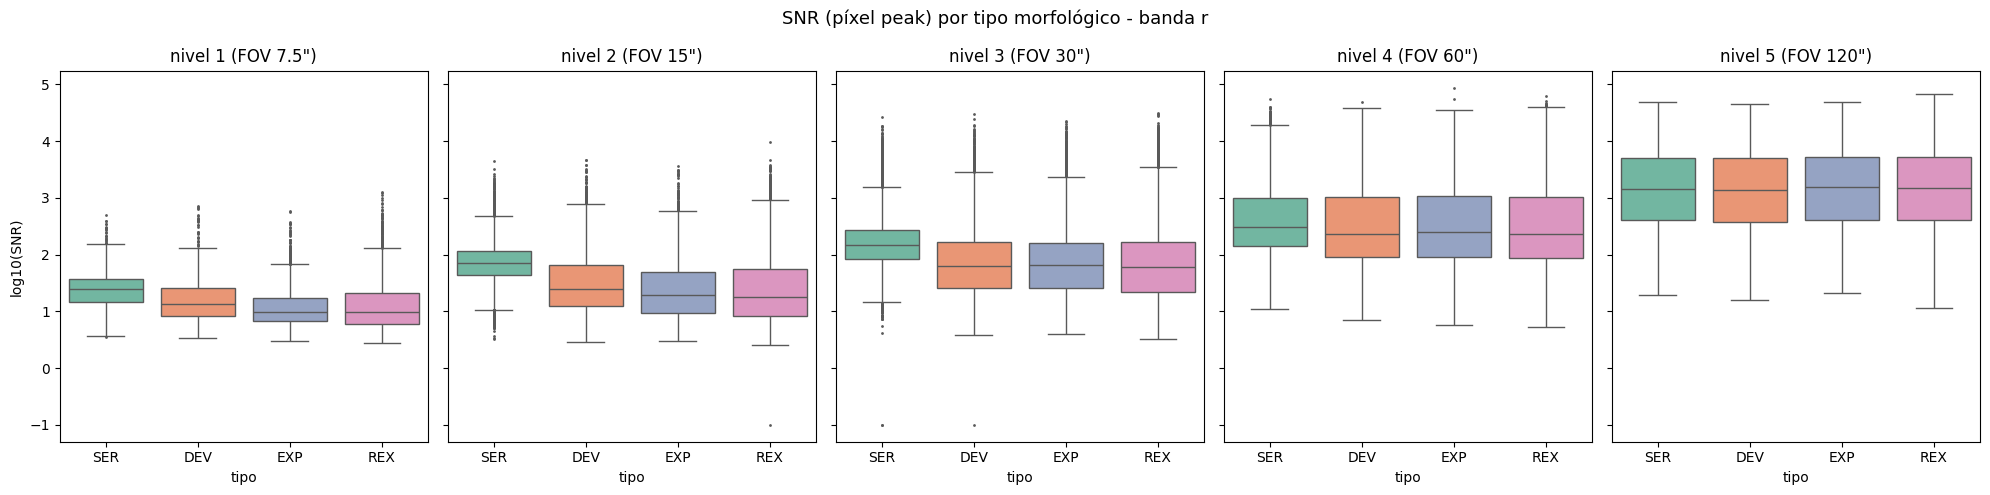

In [56]:
# SNR SEPARADO POR TIPO MORFOLÓGICO
# Requiere cruzar df_snr con df_features_images
# para obtener el tipo morfológico de cada stamp.
 
# crear mapeo id ----[ tipo desde df_features_images
id_to_type = dict(zip(
    df_features_images["desi_id"].astype(str),
    df_features_images["type"]
))
df_snr["morph_type"] = df_snr["id"].map(id_to_type)
 
print(f"Stamps con tipo asignado: {df_snr['morph_type'].notna().sum()} "
      f"de {len(df_snr)}")
 
# %%
# Boxplot de SNR por tipo morfológico, fijando banda r y nivel 3
 
fig, axes = plt.subplots(1, N_LEVELS, figsize=(20, 5), sharey=True)
fig.suptitle("SNR (píxel peak) por tipo morfológico - banda r", fontsize=13)
 
for k in range(N_LEVELS):
    ax = axes[k]
    level = k + 1
    subset = df_snr[
        (df_snr["band"] == "r") &
        (df_snr["level"] == level) &
        (df_snr["morph_type"].notna())
    ].copy()
 
    subset["log_snr"] = np.log10(subset["snr_peak"].clip(lower=0.1))
 
    sns.boxplot(data=subset, x="morph_type", y="log_snr",
                ax=ax, palette="Set2", fliersize=1)
    ax.set_title(f"nivel {level} (FOV {FOV_LABELS[k]})")
    ax.set_xlabel("tipo")
    ax.set_ylabel("log10(SNR)" if k == 0 else "")
 
plt.tight_layout()
plt.show()

/tmp/ipykernel_19440/1358421557.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="band", y="sc_std",
/tmp/ipykernel_19440/1358421557.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="band", y="sc_std",
/tmp/ipykernel_19440/1358421557.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="band", y="sc_std",
/tmp/ipykernel_19440/1358421557.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `l

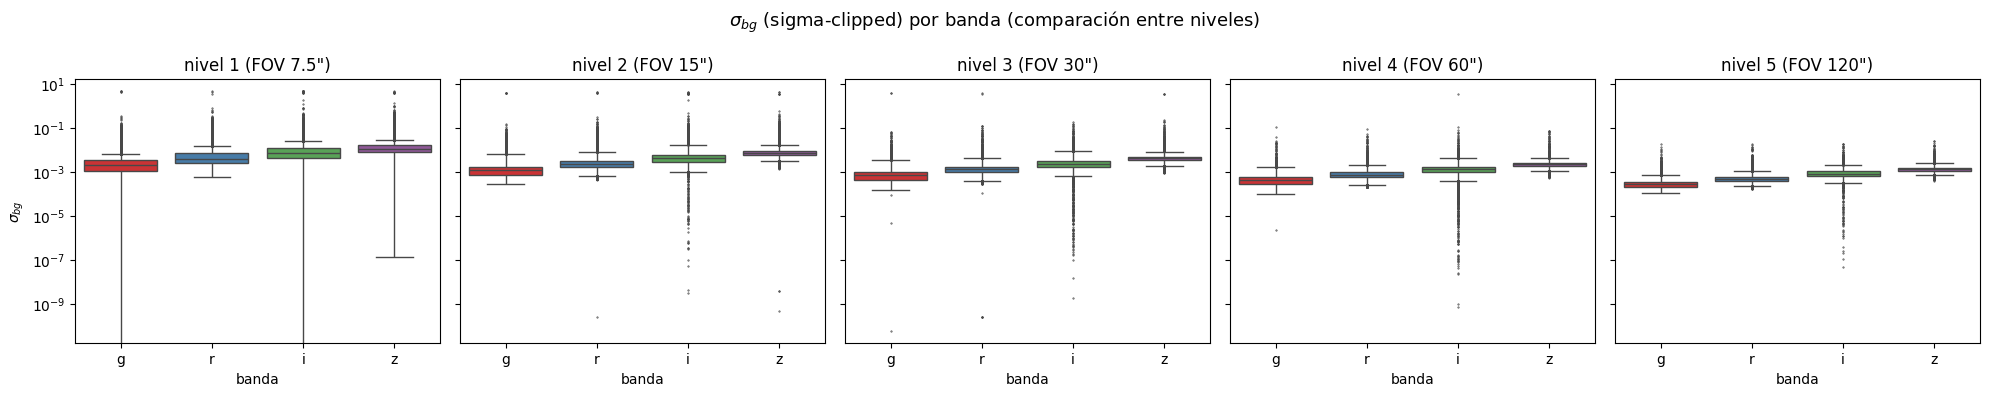

In [57]:

# COMPARAR \sigma_bg ENTRE BANDAS
# Boxplot comparativo: ¿qué banda es más ruidosa?
# Se espera que g sea la más ruidosa en Legacy Survey.
 
fig, axes = plt.subplots(1, N_LEVELS, figsize=(20, 4), sharey=True)
fig.suptitle(r"$\sigma_{bg}$ (sigma-clipped) por banda (comparación entre niveles)", fontsize=13)
 
for k in range(N_LEVELS):
    ax = axes[k]
    level = k + 1
    subset = df_sc[df_sc["level"] == level]
 
    sns.boxplot(data=subset, x="band", y="sc_std",
                ax=ax, palette="Set1", fliersize=0.5,
                order=BAND_LABELS)
    ax.set_title(f"nivel {level} (FOV {FOV_LABELS[k]})")
    ax.set_xlabel("banda")
    ax.set_ylabel(r"$\sigma_{bg}$" if k == 0 else "")
    ax.set_yscale("log")
 
plt.tight_layout()
plt.show()
 

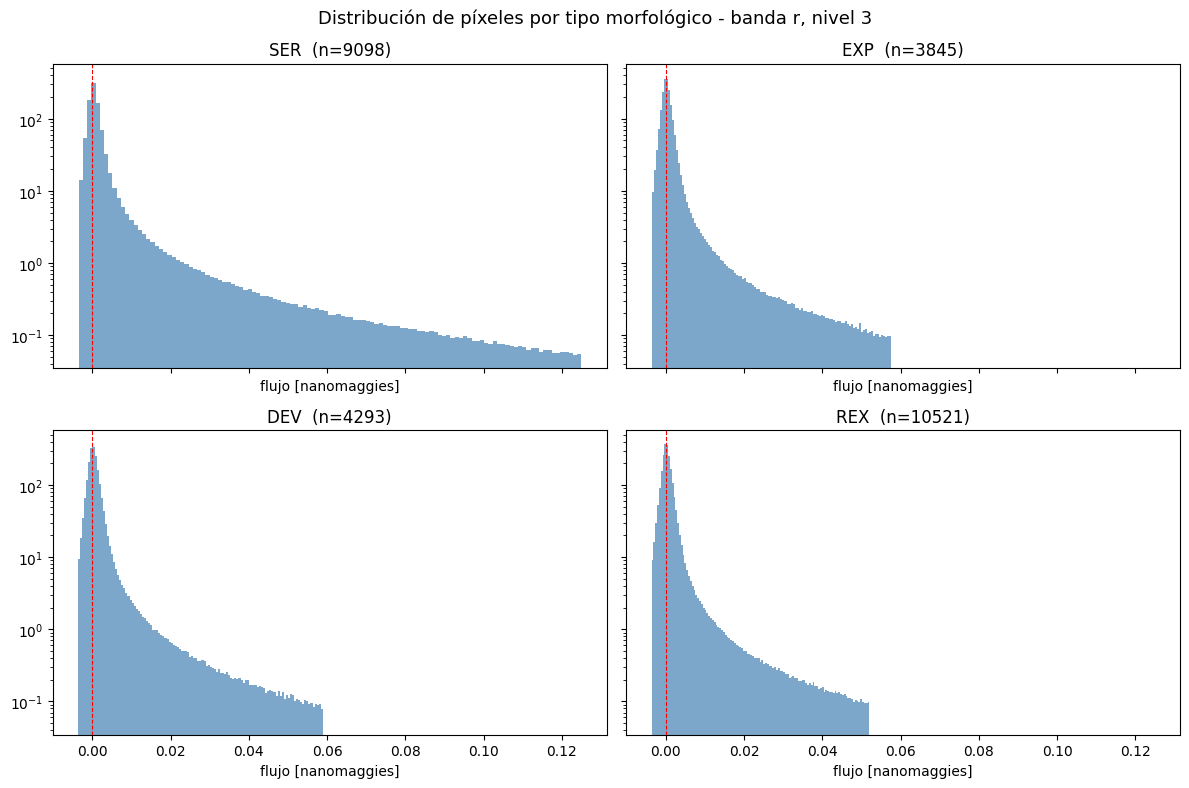

In [58]:
# =============================================
# DISTRIBUCIÓN DE PÍXELES POR TIPO MORFOLÓGICO
# Para banda r, nivel 3
# poolear todos los píxeles separando por tipo.
# Muestra si los tipos tienen distribuciones de flujo distintas.
 
# mapeo nombre --[ tipo
id_to_type_map = dict(zip(
    df_features_images["desi_id"].astype(str),
    df_features_images["type"]
))
 
BAND_IDX  = 1   # banda r
LEVEL_IDX = 2   # nivel 3
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle("Distribución de píxeles por tipo morfológico - banda r, nivel 3",
             fontsize=13)
 
types = ["SER", "EXP", "DEV", "REX"]
 
for ax, morph_type in zip(axes.flat, types):
    # recolectar píxeles solo de stamps de este tipo
    pixels_type = []
    for i in range(len(arrays)):
        name_id = names[i]
        if id_to_type_map.get(name_id) != morph_type:
            continue
        img = arrays[i][BAND_IDX, LEVEL_IDX]
        valid = img[~np.isnan(img)]
        pixels_type.append(valid)
 
    if len(pixels_type) == 0:
        ax.set_title(f"{morph_type} (sin datos)")
        continue
 
    all_px = np.concatenate(pixels_type)
    p01, p999 = np.percentile(all_px, [0.5, 99.5])
    bins = np.linspace(p01, p999, 120)
 
    ax.hist(all_px, bins=bins, density=True,
            color="steelblue", alpha=0.7, edgecolor="none")
    ax.axvline(0, color="red", ls="--", lw=0.8)
    ax.set_yscale("log")
    ax.set_title(f"{morph_type}  (n={len(pixels_type)})")
    ax.set_xlabel("flujo [nanomaggies]")
 
plt.tight_layout()
plt.show()

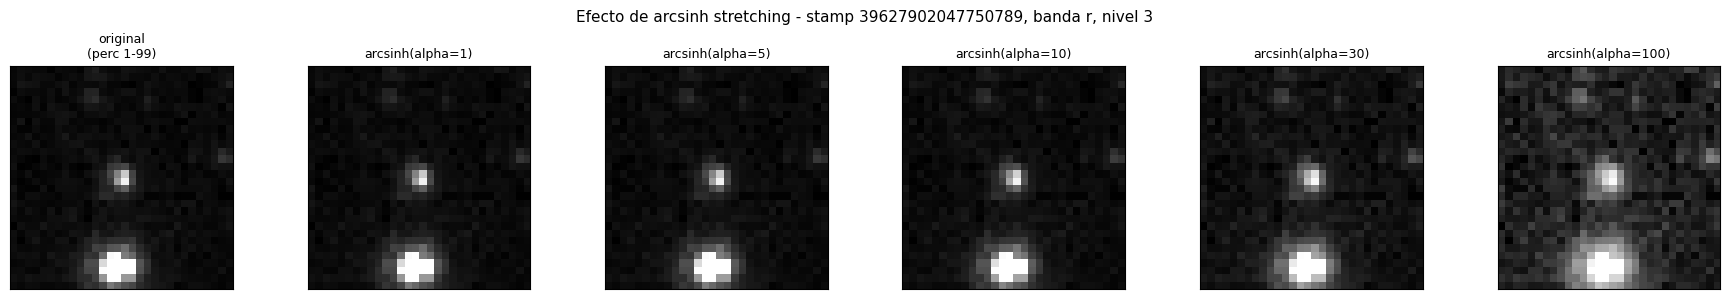

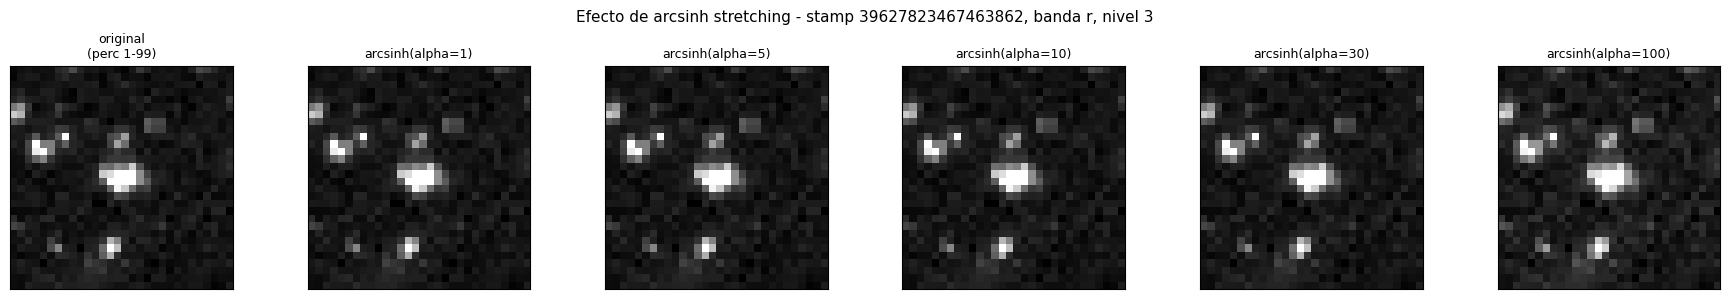

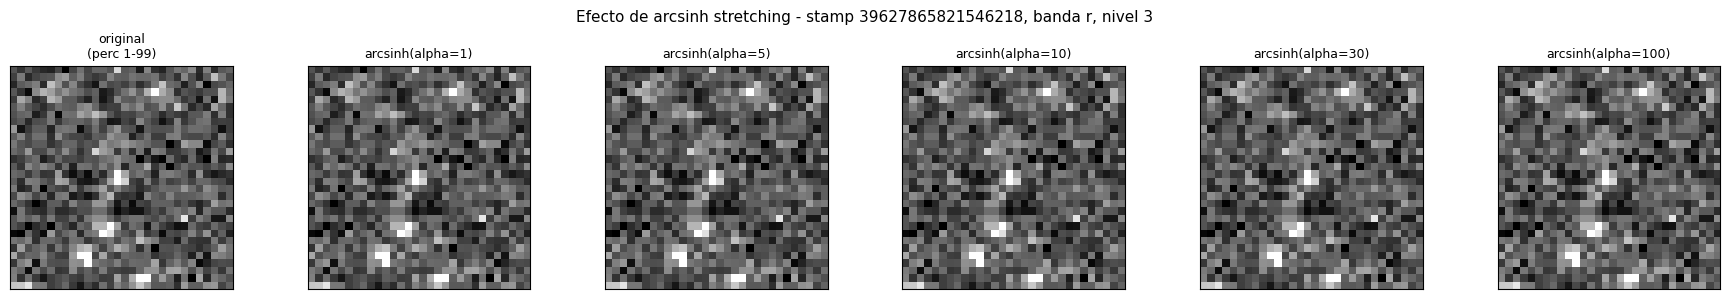

In [59]:

# VISUALIZAR EFECTO DE ARCSINH STRETCHING
# Se prueba arcsinh(\alpha * flux) con distintos \alpha
# sobre un stamp representativo para ver cómo
# cambia el contraste.
 
def plot_arcsinh_comparison(stamp_idx, band_idx=1, level_idx=2):
    """
    Muestra un stamp con distintos valores de \alpha
    en la transformación arcsinh(\alpha * flux).
    """
    img = arrays[stamp_idx][band_idx, level_idx]
    alphas = [1, 5, 10, 30, 100]
 
    fig, axes = plt.subplots(1, len(alphas) + 1, figsize=(18, 3))
    fig.suptitle(f"Efecto de arcsinh stretching - stamp {names[stamp_idx]}, "
                 f"banda {BAND_LABELS[band_idx]}, nivel {level_idx+1}",
                 fontsize=11)
 
    # original sin transformar (percentile stretch)
    ax = axes[0]
    vmin, vmax = np.nanpercentile(img, [1, 99])
    ax.imshow(np.clip((img - vmin) / (vmax - vmin + 1e-10), 0, 1),
              origin="lower", cmap="gray")
    ax.set_title("original\n(perc 1-99)", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
 
    # arcsinh con distintos \alpha
    for i, alpha in enumerate(alphas):
        ax = axes[i + 1]
        transformed = np.arcsinh(alpha * img)
        vmin, vmax = np.nanpercentile(transformed, [1, 99])
        ax.imshow(np.clip((transformed - vmin) / (vmax - vmin + 1e-10), 0, 1),
                  origin="lower", cmap="gray")
        ax.set_title(f"arcsinh(alpha={alpha})", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
 
    plt.tight_layout()
    plt.show()
 

for idx in [0, len(arrays) // 2, len(arrays) - 1]:
    plot_arcsinh_comparison(idx)
 
 


In [60]:

# RESUMEN: MÉTRICAS CLAVE POR BANDA * NIVEL
 
summary_rows = []
 
for j, band in enumerate(BAND_LABELS):
    for k in range(N_LEVELS):
        level = k + 1
        stats_sub = df_stats[(df_stats["band"] == band) & (df_stats["level"] == level)]
        sc_sub    = df_sc[(df_sc["band"] == band) & (df_sc["level"] == level)]
        snr_sub   = df_snr[(df_snr["band"] == band) & (df_snr["level"] == level)]
 
        summary_rows.append({
            "banda"            : band,
            "nivel"            : level,
            "FOV"              : FOV_LABELS[k],
            "med_flujo_stamp"  : stats_sub["median"].median(),
            "med_std_stamp"    : stats_sub["std"].median(),
            "med_sigma_bg"     : sc_sub["sc_std"].median(),
            "med_SNR_peak"     : snr_sub["snr_peak"].median(),
            "frac_SNR_lt_3"    : (snr_sub["snr_peak"].dropna() < 3).mean(),
        })
 
df_summary = pd.DataFrame(summary_rows).round(4)
print("Resumen consolidado por banda x nivel:")
print(df_summary.to_string(index=False))

Resumen consolidado por banda x nivel:
banda  nivel  FOV  med_flujo_stamp  med_std_stamp  med_sigma_bg  med_SNR_peak  frac_SNR_lt_3
    g      1 7.5"           0.0008         0.0032        0.0020       12.0920         0.0012
    g      2  15"           0.0003         0.0026        0.0012       24.1105         0.0012
    g      3  30"           0.0001         0.0025        0.0007       59.7259         0.0002
    g      4  60"           0.0001         0.0037        0.0004      207.0795         0.0000
    g      5 120"           0.0001         0.0137        0.0003     1327.3737         0.0000
    r      1 7.5"           0.0017         0.0077        0.0037       13.5271         0.0005
    r      2  15"           0.0006         0.0066        0.0022       34.4439         0.0003
    r      3  30"           0.0003         0.0069        0.0013       90.3010         0.0002
    r      4  60"           0.0002         0.0092        0.0007      279.7729         0.0000
    r      5 120"           0.0